# Model comparison — trend classification across horizons

Compares the trend classifiers on the **OFI** feature stream over the label
horizons **k ∈ {10, 20, 50, 100}**:

| tag | class | family |
|-----|-------|--------|
| `dla + ofi`            | `DLA`            | attention encoder–decoder |
| `tlob + ofi`           | `TLOB`           | temporal/spatial transformer |
| `binctabl + ofi`       | `BINCTABL`       | bilinear + BiN |
| `ctabl + ofi`          | `CTABL`          | bilinear temporal attention |
| `deeplob + ofi`        | `DeepLOB`        | CNN + inception + LSTM |
| `jumpgatelob + ofi`    | `JumpGateLOB`    | jump-diffusion score matching + noise-consistent classifier |
| `alphastablelob + ofi` | `AlphaStableLOB` | α-stable joint diffusion-classifier |

Every model exposes `predict(batch, device) → (B, 3) logits`, so the metrics
(accuracy, macro-F1, per-class F1, confusion) are computed identically.

**Sections**
1. Setup & checkpoint registry (auto-discovered, editable)
2. Load models + build the shared per-horizon test set (incl. per-window realized trend)
3. Overall metrics (accuracy / macro-F1 / per-class F1) across horizons
4. Confusion matrices
5. Metric-vs-horizon curves
6. Extreme conditions (jumps) — performance on turbulent windows
7. Financial / trading metrics — MCC/κ, signal quality, mid-price prediction
   overlay, calibration & confidence gating
8. Final model comparison table

> Run from the **Penny repo root** so the `data/` cache and `checkpoints/`
> relative paths resolve.


## 1. Setup


In [1]:
import os
import sys
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as Fn
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.metrics import (
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    recall_score,
)
from torch.utils.data import DataLoader

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda v: f"{v:.4f}")


# --- locate the repo root and chdir into it -----------------------------------
# Jupyter kernels default their cwd to wherever the server was launched (often
# the notebook's own directory, e.g. `notebooks/`), NOT the repo root. Config
# files store paths like "data/resampled/nobitex" that `build_cache` resolves
# against the *live process cwd* — so if we only add `src/` to sys.path without
# also chdir'ing, imports succeed but data loading fails with a confusing
# "parquet not found" error. Walk up from cwd to find `pyproject.toml` and
# chdir there so every relative path in every config resolves the same way
# regardless of how this notebook was launched.
def _find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() and (p / "src").is_dir():
            return p
    raise RuntimeError(
        f"could not find the Penny repo root (pyproject.toml + src/) above {start}"
    )


REPO = _find_repo_root(Path.cwd())
os.chdir(REPO)
sys.path.insert(0, str(REPO / "src"))
print("repo root:", REPO)

from crypto.dataset import build_datasets  # noqa: E402
from crypto.features import extract_features, n_features  # noqa: E402
from crypto.labels import compute_trend_series  # noqa: E402
from crypto.loader import build_cache  # noqa: E402
from models.alphastablelob import AlphaStableLOB  # noqa: E402
from models.ctabl import CTABL  # noqa: E402
from models.binctabl import BINCTABL  # noqa: E402
from models.deeplob import DeepLOB  # noqa: E402
from models.dla import DLA  # noqa: E402
from models.jumpgatelob import JumpGateLOB  # noqa: E402
from models.tlob import TLOB  # noqa: E402
from models.linvar import LinVAR  # noqa: E402
from models.logreg import LogReg  # noqa: E402
from models.ofsatnet import OFSATNet  # noqa: E402

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

repo root: /Users/arshia/Projects/Personal/Penny
device: cpu


## 2. Registry & checkpoints

`MODELS` maps each tag to its class. `HORIZONS` are the label-`k` values.

`CHECKPOINTS[model][k]` is a path to a checkpoint **directory** (containing
`best.pt`) or the `best.pt` file itself. It is auto-populated by scanning
`CHECKPOINT_ROOT` and reading each run's sibling `config.json` for
`(feature_mode, label_k, symbol)` — the newest run wins. **Edit the printed dict
to point at the exact checkpoints you want.**

In [2]:
FEATURE_MODE = "ofi"
SYMBOL = "BNBIRT"
HORIZONS = [10, 20, 50, 100]
BATCH = 256

# tag -> (class, checkpoint-dir prefix written by the train scripts)
MODELS = {
    "dla": (DLA, "dla_"),
    # "axial": (AxialLOB, "axiallob_"),
    "tlob": (TLOB, "tlob_"),
    "ctabl": (CTABL, "ctabl_"),
    "binctabl": (BINCTABL, "binctabl_"),
    "deeplob": (DeepLOB, "deeplob_"),
    "alphastablelob_1.5": (AlphaStableLOB, "alphastablelob_joint_a1.5_"),
    # "alphastablelob_1.7": (AlphaStableLOB, "alphastablelob_joint_a17"),
    "linvar": (LinVAR, "linvar_"),
    "logreg": (LogReg, "logreg_"),
    "jumpgatelob": (JumpGateLOB, "jumpgatelob_"),
    "ofsatnet": (OFSATNet, "ofsatnet_"),
}
LABELS = ["down", "stationary", "up"]
DISPLAY = {m: f"{m} + {FEATURE_MODE}" for m in MODELS}

# where to scan for runs (change if your checkpoints live elsewhere)
CHECKPOINT_ROOT = REPO / "checkpoints" / "nobitex" / SYMBOL

# JSON config used only to BUILD the shared test set for each horizon.
# Any model's ofi config for that k works (identical data params); jumpgatelob
# ships one per horizon.
DATA_CONFIG = "configs/crypto/nobitex/jumpgatelob/bnbirt_{fm}_k{k}.json"


def _run_config(run_dir: Path) -> dict | None:
    """Read a run's sidecar config.json (falls back to best.pt if absent)."""
    cj = run_dir / "config.json"
    if cj.exists():
        try:
            return json.loads(cj.read_text())
        except Exception:
            pass
    bp = run_dir / "best.pt"
    if bp.exists():
        try:
            return torch.load(bp, map_location="cpu", weights_only=False)["config"]
        except Exception:
            pass
    return None


def discover_checkpoints() -> dict:
    """tag -> {k -> newest matching run dir}, matched on prefix + config."""
    found = {m: {} for m in MODELS}
    if not CHECKPOINT_ROOT.exists():
        print(f"! CHECKPOINT_ROOT does not exist: {CHECKPOINT_ROOT}")
        return found
    for run in sorted(CHECKPOINT_ROOT.iterdir()):  # lexical == chronological
        if not run.is_dir():
            continue
        for tag, (_cls, prefix) in MODELS.items():
            if not run.name.startswith(prefix):
                continue
            cfg = _run_config(run)
            if cfg is None:
                continue
            k = cfg.get("label_k")
            if (
                cfg.get("feature_mode") == FEATURE_MODE
                and cfg.get("symbol") == SYMBOL
                and k in HORIZONS
            ):
                found[tag][k] = str(run)  # newest overwrites
    return found


CHECKPOINTS = discover_checkpoints()
print("Auto-discovered checkpoints (edit below if needed):\n")
for m in MODELS:
    row = ", ".join(f"k{k}:{'✓' if k in CHECKPOINTS[m] else '—'}" for k in HORIZONS)
    print(f"  {DISPLAY[m]:<24} {row}")
CHECKPOINTS

Auto-discovered checkpoints (edit below if needed):

  dla + ofi                k10:✓, k20:✓, k50:✓, k100:✓
  tlob + ofi               k10:✓, k20:✓, k50:✓, k100:✓
  ctabl + ofi              k10:✓, k20:✓, k50:✓, k100:✓
  binctabl + ofi           k10:✓, k20:✓, k50:✓, k100:✓
  deeplob + ofi            k10:✓, k20:✓, k50:✓, k100:✓
  alphastablelob_1.5 + ofi k10:✓, k20:✓, k50:✓, k100:✓
  linvar + ofi             k10:✓, k20:✓, k50:✓, k100:✓
  logreg + ofi             k10:✓, k20:✓, k50:✓, k100:✓
  jumpgatelob + ofi        k10:✓, k20:✓, k50:✓, k100:✓
  ofsatnet + ofi           k10:✓, k20:✓, k50:✓, k100:✓


{'dla': {10: '/Users/arshia/Projects/Personal/Penny/checkpoints/nobitex/BNBIRT/dla_BNBIRT_ofi_k10',
  100: '/Users/arshia/Projects/Personal/Penny/checkpoints/nobitex/BNBIRT/dla_BNBIRT_ofi_k100',
  20: '/Users/arshia/Projects/Personal/Penny/checkpoints/nobitex/BNBIRT/dla_BNBIRT_ofi_k20',
  50: '/Users/arshia/Projects/Personal/Penny/checkpoints/nobitex/BNBIRT/dla_BNBIRT_ofi_k50'},
 'tlob': {10: '/Users/arshia/Projects/Personal/Penny/checkpoints/nobitex/BNBIRT/tlob_BNBIRT_ofi_k10',
  100: '/Users/arshia/Projects/Personal/Penny/checkpoints/nobitex/BNBIRT/tlob_BNBIRT_ofi_k100',
  20: '/Users/arshia/Projects/Personal/Penny/checkpoints/nobitex/BNBIRT/tlob_BNBIRT_ofi_k20',
  50: '/Users/arshia/Projects/Personal/Penny/checkpoints/nobitex/BNBIRT/tlob_BNBIRT_ofi_k50'},
 'ctabl': {10: '/Users/arshia/Projects/Personal/Penny/checkpoints/nobitex/BNBIRT/ctabl_BNBIRT_ofi_k10',
  100: '/Users/arshia/Projects/Personal/Penny/checkpoints/nobitex/BNBIRT/ctabl_BNBIRT_ofi_k100',
  20: '/Users/arshia/Projects/

## 3. Load models & evaluate

The test set is built **once per horizon** and shared across all models, so
every model is scored on the identical windows and labels. For each window we
also record a **stress score** — the repo's own market-jump measure
(`_data_jump_flag`): the largest 1-step increment of the level-averaged feature,
in realized-volatility units. Higher ⇒ more turbulent input.

In [3]:
def load_ckpt(path: str):
    p = Path(path)
    if p.is_dir():
        p = p / "best.pt"
    return torch.load(p, map_location=DEVICE, weights_only=False)


def build_model(tag: str, ckpt: dict):
    cls, _ = MODELS[tag]
    model = cls(ckpt["config"]).to(DEVICE)
    model.load_state_dict(ckpt["model"])
    model.eval()
    return model


_DS_CACHE: dict[int, tuple] = {}
# META[k] = {"mid", "ts", "centres", "trend", "alpha"} — per-window financial
# ground truth: `centres` indexes each test window's label bin into the full
# `mid`/`ts` series; `trend` is the realized smoothed trend_ratio at that bin
# (the exact quantity the ±alpha label thresholds), used by section 7.
META: dict[int, dict] = {}


def test_set(k: int):
    """(test_ds, y_true, stress) for horizon k — built once, then cached."""
    if k in _DS_CACHE:
        return _DS_CACHE[k]
    cfg_path = REPO / DATA_CONFIG.format(fm=FEATURE_MODE, k=k)
    cfg = json.loads(cfg_path.read_text())
    _, _, test_ds, alpha, meta = build_datasets(cfg)
    loader = DataLoader(test_ds, batch_size=BATCH, shuffle=False)
    ys, ss = [], []
    for b in loader:
        x = b["x"].float()  # (B, 1, T, F)
        agg = x.squeeze(1).mean(-1)  # (B, T) level-averaged stream
        dif = agg[:, 1:] - agg[:, :-1]
        rv = dif.std(dim=1).clamp_min(1e-8)
        ss.append((dif.abs().max(dim=1).values / rv).numpy())
        ys.append(b["label"].numpy())
    y_true = np.concatenate(ys)
    stress = np.concatenate(ss)

    # financial ground truth: mid series + realized trend at each window centre
    feat, mid, ts = build_cache(cfg, extract_features, n_features, tag="lob")
    centres = np.asarray(test_ds.starts) + cfg["T_past"] - 1
    trend = compute_trend_series(mid, k)[centres]
    lab_chk = np.where(trend > alpha, 2, np.where(trend < -alpha, 0, 1))
    mism = float((lab_chk != y_true).mean())
    if mism > 1e-3:
        print(f"  ! label/trend mismatch {mism:.2%} — check alpha/config alignment")
    META[k] = {"mid": mid, "ts": ts, "centres": centres, "trend": trend, "alpha": alpha}

    print(
        f"  k={k:<3} test windows={len(y_true):>6}  "
        f"class balance {np.bincount(y_true, minlength=3) / len(y_true)}  "
        f"mean |trend|={np.abs(trend).mean() * 1e4:.2f} bp"
    )
    _DS_CACHE[k] = (test_ds, y_true, stress)
    return _DS_CACHE[k]


@torch.no_grad()
def evaluate(model, test_ds):
    loader = DataLoader(test_ds, batch_size=BATCH, shuffle=False)
    yt, yp, pr = [], [], []
    for b in loader:
        logits = model.predict(b, DEVICE)
        pr.append(Fn.softmax(logits, dim=1).cpu().numpy())
        yp.append(logits.argmax(dim=1).cpu().numpy())
        yt.append(b["label"].numpy())
    return np.concatenate(yt), np.concatenate(yp), np.concatenate(pr)

In [4]:
# RESULTS[(tag, k)] = {"y_true", "y_pred", "probs", "stress"}
RESULTS: dict = {}

for k in HORIZONS:
    print(f"horizon k={k}")
    try:
        test_ds, y_true, stress = test_set(k)
    except FileNotFoundError as e:
        print(f"  ! could not build test set for k={k}: {e}")
        print(
            f"    (cwd is {Path.cwd()} — if this looks wrong, re-run the setup "
            f"cell; if the file is genuinely missing, run `uv run dvc pull`)"
        )
        continue
    except Exception as e:
        print(f"  ! could not build test set for k={k}: {e}")
        continue
    for tag in MODELS:
        path = CHECKPOINTS.get(tag, {}).get(k)
        if not path or not Path(path).exists():
            print(f"  {DISPLAY[tag]:<24} — no checkpoint, skipped")
            continue
        ckpt = load_ckpt(path)
        cfg = ckpt["config"]
        if cfg.get("label_k") != k or cfg.get("feature_mode") != FEATURE_MODE:
            print(
                f"  {DISPLAY[tag]:<24} ! config mismatch "
                f"(k={cfg.get('label_k')}, fm={cfg.get('feature_mode')}), skipped"
            )
            continue
        model = build_model(tag, ckpt)
        yt, yp, pr = evaluate(model, test_ds)
        assert np.array_equal(yt, y_true), "window/label misalignment"
        RESULTS[(tag, k)] = {"y_true": yt, "y_pred": yp, "probs": pr, "stress": stress}
        acc = (yt == yp).mean()
        f1 = f1_score(yt, yp, average="macro", labels=[0, 1, 2], zero_division=0)
        print(f"  {DISPLAY[tag]:<24} acc={acc:.4f}  macro_f1={f1:.4f}")
        del model
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()

print(f"\nevaluated {len(RESULTS)} (model, horizon) pairs")

horizon k=10


2026-07-24 13:15:57.170 | INFO     | crypto.loader:build_cache:115 - loaded cache 'lob': 213,679 rows, 31 features
2026-07-24 13:15:58.725 | INFO     | crypto.dataset:build_datasets:86 - windows — train:147524 val:31882 test:31983
2026-07-24 13:15:58.941 | INFO     | crypto.loader:build_cache:115 - loaded cache 'lob': 213,679 rows, 31 features


  k=10  test windows= 31983  class balance [0.30738205 0.36728887 0.32532908]  mean |trend|=3.50 bp
  dla + ofi                acc=0.7064  macro_f1=0.7069
  tlob + ofi               acc=0.6856  macro_f1=0.6858
  ctabl + ofi              acc=0.7062  macro_f1=0.7064
  binctabl + ofi           acc=0.6765  macro_f1=0.6771
  deeplob + ofi            acc=0.6405  macro_f1=0.6357
  alphastablelob_1.5 + ofi acc=0.7096  macro_f1=0.7086
  linvar + ofi             acc=0.6863  macro_f1=0.6855
  logreg + ofi             acc=0.6730  macro_f1=0.6725
  jumpgatelob + ofi        acc=0.7019  macro_f1=0.7006


2026-07-24 13:17:45.047 | INFO     | crypto.loader:build_cache:115 - loaded cache 'lob': 213,679 rows, 31 features


  ofsatnet + ofi           acc=0.7012  macro_f1=0.7005
horizon k=20


...

  k=50  test windows= 31943  class balance [0.2998153  0.3954231  0.30476161]  mean |trend|=7.93 bp
  dla + ofi                acc=0.5952  macro_f1=0.5990
  tlob + ofi               acc=0.5510  macro_f1=0.5481
  ctabl + ofi              acc=0.5868  macro_f1=0.5898
  binctabl + ofi           acc=0.5446  macro_f1=0.5469
  deeplob + ofi            acc=0.4515  macro_f1=0.4472
  alphastablelob_1.5 + ofi acc=0.5660  macro_f1=0.5691
  linvar + ofi             acc=0.5822  macro_f1=0.5860
  logreg + ofi             acc=0.5803  macro_f1=0.5837
  jumpgatelob + ofi        acc=0.5742  macro_f1=0.5768


2026-07-24 13:20:58.169 | INFO     | crypto.loader:build_cache:115 - loaded cache 'lob': 213,679 rows, 31 features


  ofsatnet + ofi           acc=0.5561  macro_f1=0.5582
horizon k=100


2026-07-24 13:20:59.668 | INFO     | crypto.dataset:build_datasets:86 - windows — train:147393 val:31792 test:31893
2026-07-24 13:20:59.892 | INFO     | crypto.loader:build_cache:115 - loaded cache 'lob': 213,679 rows, 31 features


  k=100 test windows= 31893  class balance [0.28978146 0.40303515 0.30718339]  mean |trend|=10.57 bp
  dla + ofi                acc=0.5448  macro_f1=0.5491
  tlob + ofi               acc=0.5049  macro_f1=0.5065
  ctabl + ofi              acc=0.5198  macro_f1=0.5222
  binctabl + ofi           acc=0.4804  macro_f1=0.4833
  deeplob + ofi            acc=0.4020  macro_f1=0.3787
  alphastablelob_1.5 + ofi acc=0.5057  macro_f1=0.5093
  linvar + ofi             acc=0.5334  macro_f1=0.5366
  logreg + ofi             acc=0.5352  macro_f1=0.5378
  jumpgatelob + ofi        acc=0.5086  macro_f1=0.5113
  ofsatnet + ofi           acc=0.5039  macro_f1=0.5052

evaluated 40 (model, horizon) pairs


## 4. Overall metrics

In [5]:
def metrics_row(yt, yp):
    per_f1 = f1_score(yt, yp, average=None, labels=[0, 1, 2], zero_division=0)
    return {
        "accuracy": (yt == yp).mean(),
        "macro_f1": f1_score(
            yt, yp, average="macro", labels=[0, 1, 2], zero_division=0
        ),
        "f1_down": per_f1[0],
        "f1_stat": per_f1[1],
        "f1_up": per_f1[2],
    }


rows = []
for (tag, k), r in RESULTS.items():
    rows.append(
        {"model": DISPLAY[tag], "k": k, **metrics_row(r["y_true"], r["y_pred"])}
    )

metrics_df = pd.DataFrame(rows).sort_values(["k", "model"]).reset_index(drop=True)
metrics_df

,model,k,accuracy,macro_f1,f1_down,f1_stat,f1_up
0,alphastablelob_1.5 + ofi,10,0.7096,0.7086,0.7058,0.7176,0.7024
1,binctabl + ofi,10,0.6765,0.6771,0.6838,0.6728,0.6747
2,ctabl + ofi,10,0.7062,0.7064,0.7085,0.7051,0.7055
3,deeplob + ofi,10,0.6405,0.6357,0.6196,0.6805,0.6071
4,dla + ofi,10,0.7064,0.7069,0.7056,0.7020,0.7132
5,jumpgatelob + ofi,10,0.7019,0.7006,0.6923,0.7097,0.6999
6,linvar + ofi,10,0.6863,0.6855,0.6802,0.6909,0.6853
7,logreg + ofi,10,0.6730,0.6725,0.6681,0.6756,0.6738
8,ofsatnet + ofi,10,0.7012,0.7005,0.6972,0.7069,0.6974
9,tlob + ofi,10,0.6856,0.6858,0.6874,0.6833,0.6867


In [6]:
# accuracy & macro-F1 pivots (rows = model, cols = horizon)
if not metrics_df.empty:
    order = [DISPLAY[m] for m in MODELS if DISPLAY[m] in set(metrics_df["model"])]
    for metric in ["accuracy", "macro_f1"]:
        piv = metrics_df.pivot(index="model", columns="k", values=metric).reindex(order)
        print(f"\n=== {metric} (rows=model, cols=horizon k) ===")
        display(piv.style.background_gradient(cmap="YlGn", axis=None).format("{:.4f}"))


=== accuracy (rows=model, cols=horizon k) ===


k,10,20,50,100
model,,,,
dla + ofi,0.7064,0.6474,0.5952,0.5448
tlob + ofi,0.6856,0.6247,0.5510,0.5049
ctabl + ofi,0.7062,0.6411,0.5868,0.5198
binctabl + ofi,0.6765,0.6068,0.5446,0.4804
deeplob + ofi,0.6405,0.5547,0.4515,0.4020
alphastablelob_1.5 + ofi,0.7096,0.6227,0.5660,0.5057
linvar + ofi,0.6863,0.6467,0.5822,0.5334
logreg + ofi,0.6730,0.6320,0.5803,0.5352
jumpgatelob + ofi,0.7019,0.6356,0.5742,0.5086



=== macro_f1 (rows=model, cols=horizon k) ===


k,10,20,50,100
model,,,,
dla + ofi,0.7069,0.6501,0.5990,0.5491
tlob + ofi,0.6858,0.6252,0.5481,0.5065
ctabl + ofi,0.7064,0.6434,0.5898,0.5222
binctabl + ofi,0.6771,0.6084,0.5469,0.4833
deeplob + ofi,0.6357,0.5533,0.4472,0.3787
alphastablelob_1.5 + ofi,0.7086,0.6244,0.5691,0.5093
linvar + ofi,0.6855,0.6493,0.5860,0.5366
logreg + ofi,0.6725,0.6343,0.5837,0.5378
jumpgatelob + ofi,0.7006,0.6367,0.5768,0.5113


## 5. Confusion matrices

Row-normalized (recall per true class). One row of panels per horizon.

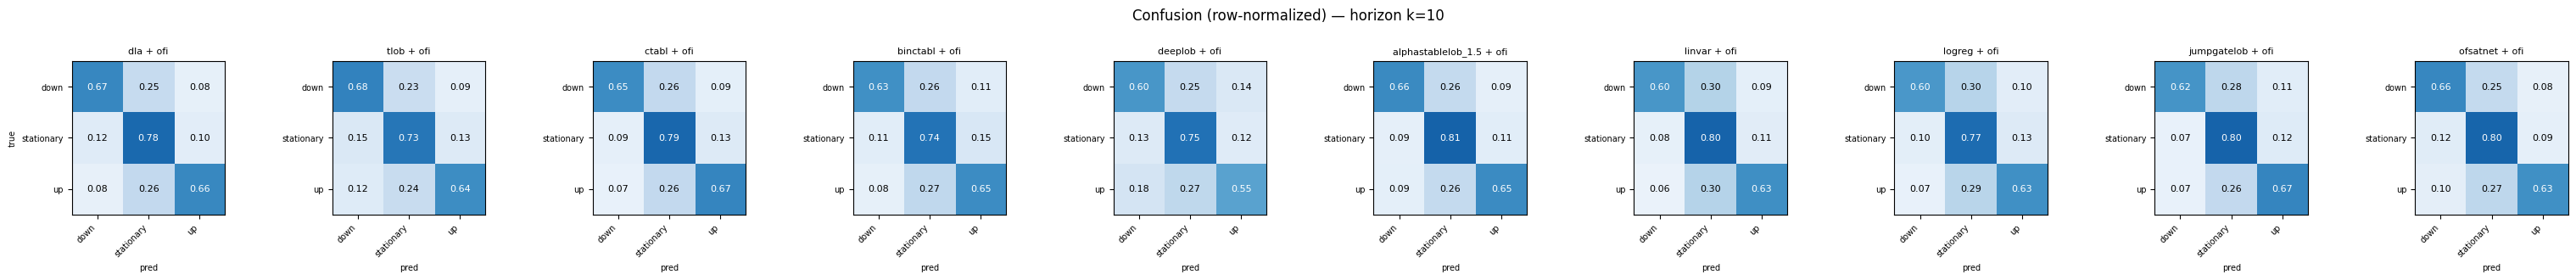

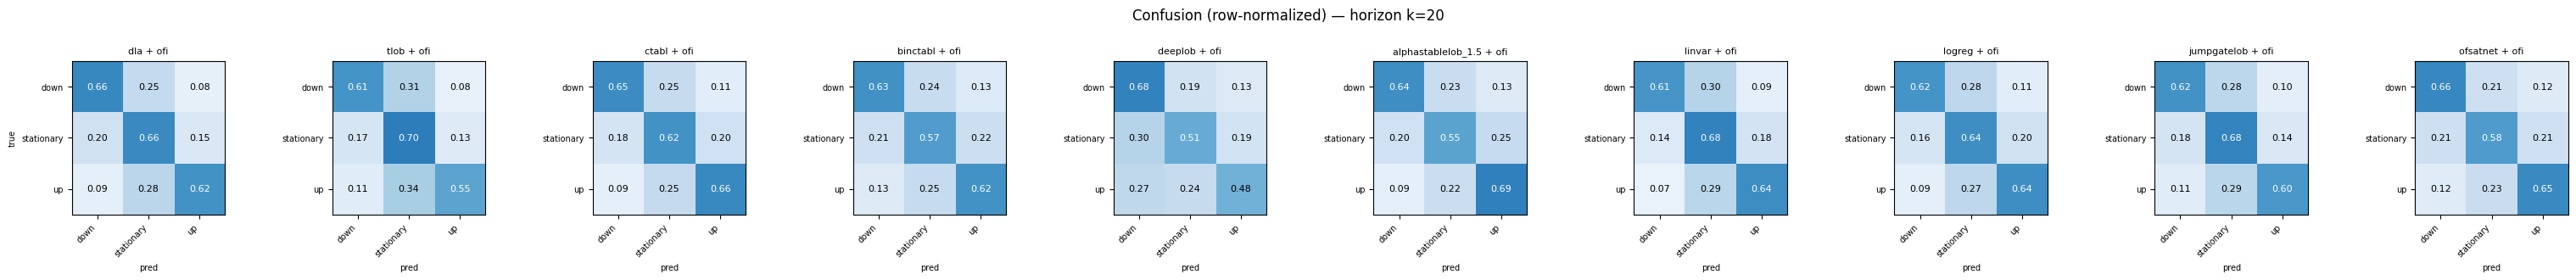

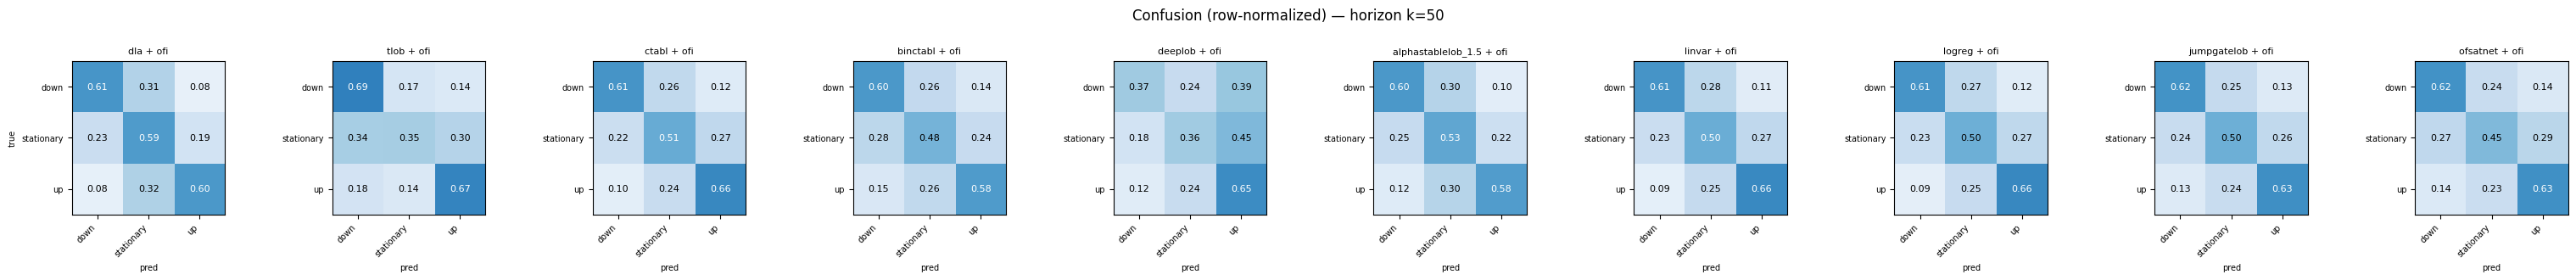

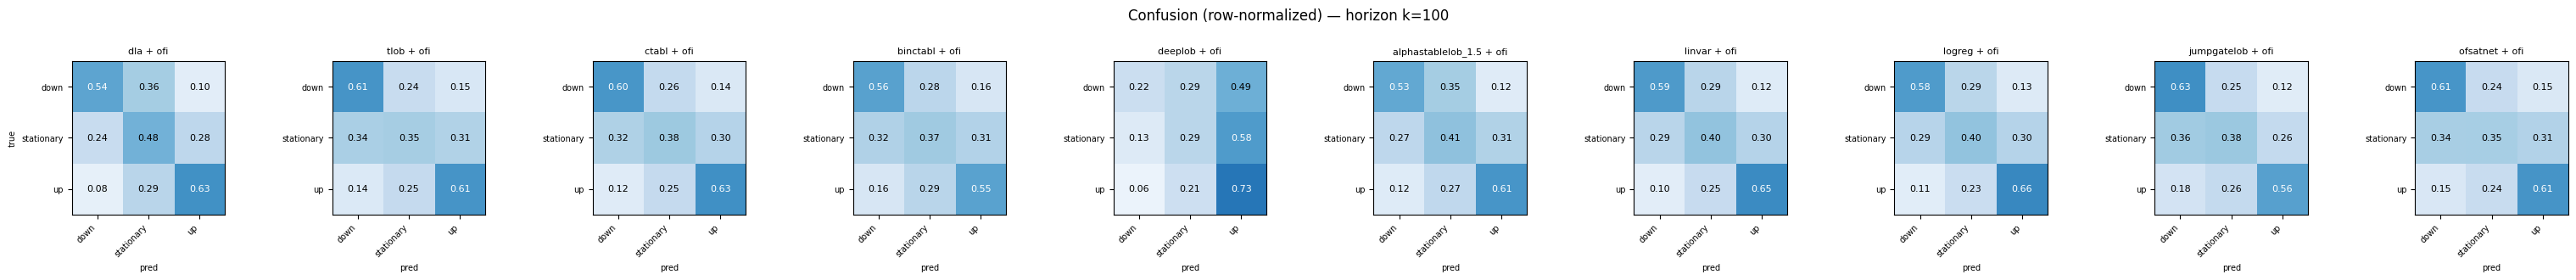

In [7]:
def plot_confusions(k):
    tags = [t for t in MODELS if (t, k) in RESULTS]
    if not tags:
        return
    fig, axes = plt.subplots(
        1, len(tags), figsize=(3.1 * len(tags), 3.0), squeeze=False
    )
    for ax, tag in zip(axes[0], tags):
        r = RESULTS[(tag, k)]
        cm = confusion_matrix(r["y_true"], r["y_pred"], labels=[0, 1, 2]).astype(float)
        cmn = cm / cm.sum(1, keepdims=True).clip(min=1)
        _ = ax.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
        for i in range(3):
            for j in range(3):
                ax.text(
                    j,
                    i,
                    f"{cmn[i, j]:.2f}",
                    ha="center",
                    va="center",
                    color="white" if cmn[i, j] > 0.5 else "black",
                    fontsize=8,
                )
        ax.set_xticks(range(3), LABELS, rotation=45, ha="right", fontsize=7)
        ax.set_yticks(range(3), LABELS, fontsize=7)
        ax.set_title(DISPLAY[tag], fontsize=8)
        ax.set_xlabel("pred", fontsize=7)
    axes[0][0].set_ylabel("true", fontsize=7)
    fig.suptitle(f"Confusion (row-normalized) — horizon k={k}", y=1.04)
    fig.tight_layout()
    plt.show()


for k in HORIZONS:
    plot_confusions(k)

## 6. Metric vs horizon

How each model's accuracy and macro-F1 evolve as the prediction horizon grows.

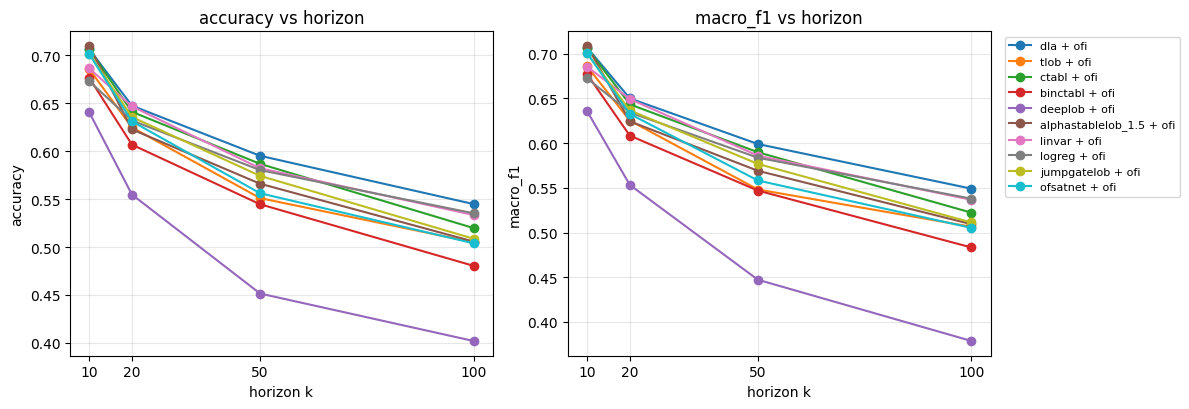

In [8]:
if not metrics_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
    cmap = plt.get_cmap("tab10")
    present = [m for m in MODELS if DISPLAY[m] in set(metrics_df["model"])]
    for metric, ax in zip(["accuracy", "macro_f1"], axes):
        for i, tag in enumerate(present):
            sub = metrics_df[metrics_df["model"] == DISPLAY[tag]].sort_values("k")
            ax.plot(sub["k"], sub[metric], "o-", color=cmap(i % 10), label=DISPLAY[tag])
        ax.set_xlabel("horizon k")
        ax.set_ylabel(metric)
        ax.set_title(f"{metric} vs horizon")
        ax.set_xticks(HORIZONS)
        ax.grid(alpha=0.3)
    axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    fig.tight_layout()
    plt.show()

## 7. Extreme conditions (jumps)

Windows are split by their **stress score** (RV-normalized max increment). We
compare performance on **calm** vs **extreme** windows, where *extreme* = the top
`EXTREME_Q` quantile of stress **within each horizon** (guarantees non-empty
buckets). A large `Δ = calm − extreme` means a model degrades under turbulence;
a small Δ means it is jump-robust.

In [9]:
EXTREME_Q = 0.90  # top 10% most turbulent windows = "extreme"


def split_metrics(r, thr):
    st = r["stress"]
    calm, extr = st <= thr, st > thr
    out = {}
    for name, mask in [("calm", calm), ("extreme", extr)]:
        if mask.sum() == 0:
            out[name] = {"n": 0, "accuracy": np.nan, "macro_f1": np.nan}
            continue
        yt, yp = r["y_true"][mask], r["y_pred"][mask]
        out[name] = {
            "n": int(mask.sum()),
            "accuracy": (yt == yp).mean(),
            "macro_f1": f1_score(
                yt, yp, average="macro", labels=[0, 1, 2], zero_division=0
            ),
        }
    return out


rows = []
for (tag, k), r in RESULTS.items():
    thr = np.quantile(r["stress"], EXTREME_Q)
    s = split_metrics(r, thr)
    rows.append(
        {
            "model": DISPLAY[tag],
            "k": k,
            "acc_calm": s["calm"]["accuracy"],
            "acc_extreme": s["extreme"]["accuracy"],
            "f1_calm": s["calm"]["macro_f1"],
            "f1_extreme": s["extreme"]["macro_f1"],
            "f1_drop": s["calm"]["macro_f1"] - s["extreme"]["macro_f1"],
            "n_extreme": s["extreme"]["n"],
        }
    )
extreme_df = pd.DataFrame(rows).sort_values(["k", "model"]).reset_index(drop=True)
extreme_df

,model,k,acc_calm,acc_extreme,f1_calm,f1_extreme,f1_drop,n_extreme
0,alphastablelob_1.5 + ofi,10,0.7070,0.7334,0.7063,0.7290,-0.0227,3199
1,binctabl + ofi,10,0.6728,0.7102,0.6737,0.7073,-0.0337,3199
2,ctabl + ofi,10,0.7026,0.7384,0.7031,0.7356,-0.0325,3199
3,deeplob + ofi,10,0.6371,0.6711,0.6327,0.6630,-0.0303,3199
4,dla + ofi,10,0.7022,0.7443,0.7030,0.7411,-0.0381,3199
5,jumpgatelob + ofi,10,0.6981,0.7355,0.6972,0.7310,-0.0338,3199
6,linvar + ofi,10,0.6833,0.7133,0.6827,0.7100,-0.0273,3199
7,logreg + ofi,10,0.6688,0.7102,0.6687,0.7061,-0.0374,3199
8,ofsatnet + ofi,10,0.6981,0.7299,0.6976,0.7256,-0.0280,3199
9,tlob + ofi,10,0.6821,0.7171,0.6826,0.7147,-0.0322,3199


In [10]:
# macro-F1 drop under stress (rows=model, cols=horizon) — lower is more robust
if not extreme_df.empty:
    order = [DISPLAY[m] for m in MODELS if DISPLAY[m] in set(extreme_df["model"])]
    piv = extreme_df.pivot(index="model", columns="k", values="f1_drop").reindex(order)
    print("=== macro-F1 drop (calm − extreme); lower = more jump-robust ===")
    display(piv.style.background_gradient(cmap="Reds", axis=None).format("{:.4f}"))

=== macro-F1 drop (calm − extreme); lower = more jump-robust ===


k,10,20,50,100
model,,,,
dla + ofi,-0.0381,-0.0244,0.0090,0.0477
tlob + ofi,-0.0322,-0.0147,0.0060,0.0284
ctabl + ofi,-0.0325,-0.0257,0.0054,0.0077
binctabl + ofi,-0.0337,-0.0334,-0.0256,-0.0101
deeplob + ofi,-0.0303,-0.0497,-0.0071,0.0021
alphastablelob_1.5 + ofi,-0.0227,-0.0449,-0.0376,0.0547
linvar + ofi,-0.0273,-0.0351,-0.0089,0.0475
logreg + ofi,-0.0374,-0.0329,-0.0252,0.0207
jumpgatelob + ofi,-0.0338,-0.0417,-0.0345,0.0283


### Accuracy vs stress decile

Windows binned into stress deciles; per-model accuracy in each bin. The right side of each panel is the turbulent regime.

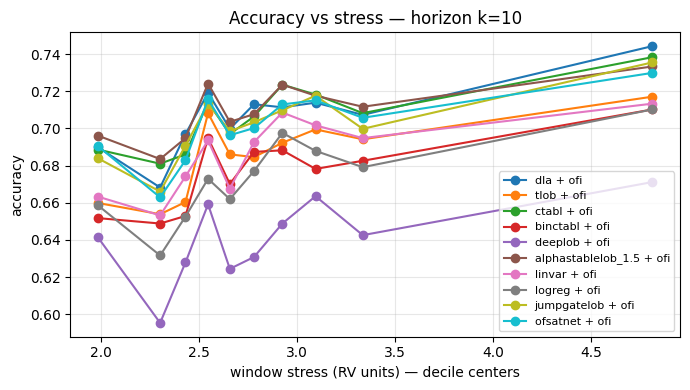

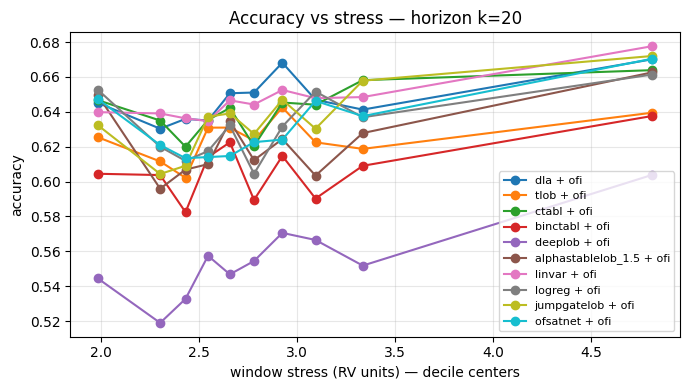

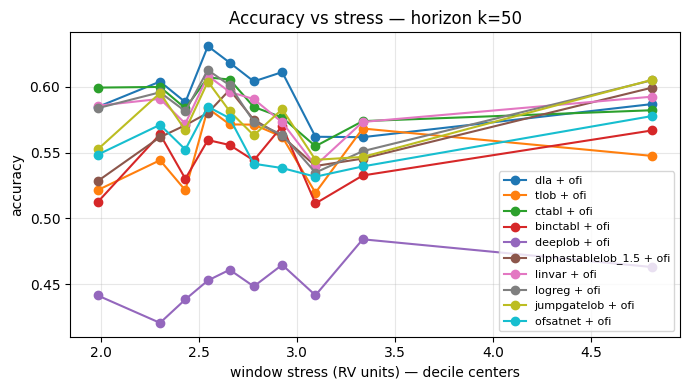

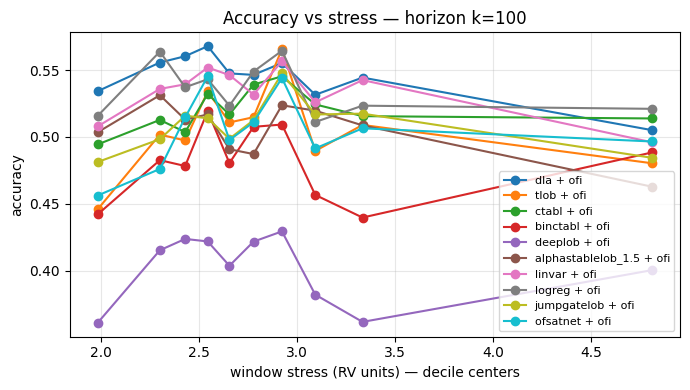

In [11]:
def plot_stress_curves(k, n_bins=10):
    tags = [t for t in MODELS if (t, k) in RESULTS]
    if not tags:
        return None
    stress = RESULTS[(tags[0], k)]["stress"]
    edges = np.quantile(stress, np.linspace(0, 1, n_bins + 1))
    edges[-1] += 1e-9
    centers = 0.5 * (edges[:-1] + edges[1:])
    cmap = plt.get_cmap("tab10")
    fig, ax = plt.subplots(figsize=(7, 4))
    for i, tag in enumerate(tags):
        r = RESULTS[(tag, k)]
        correct = (r["y_true"] == r["y_pred"]).astype(float)
        idx = np.clip(np.digitize(r["stress"], edges) - 1, 0, n_bins - 1)
        acc = [
            correct[idx == b].mean() if (idx == b).any() else np.nan
            for b in range(n_bins)
        ]
        ax.plot(centers, acc, "o-", color=cmap(i % 10), label=DISPLAY[tag])
    ax.set_xlabel("window stress (RV units) — decile centers")
    ax.set_ylabel("accuracy")
    ax.set_title(f"Accuracy vs stress — horizon k={k}")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()


for k in HORIZONS:
    plot_stress_curves(k)

### Catching the big moves

In the extreme bucket, per-class **recall** for `down` and `up` — does the model still flag large directional moves when they happen?

In [12]:
rows = []
for (tag, k), r in RESULTS.items():
    thr = np.quantile(r["stress"], EXTREME_Q)
    mask = r["stress"] > thr
    if mask.sum() == 0:
        continue
    yt, yp = r["y_true"][mask], r["y_pred"][mask]
    rec = recall_score(yt, yp, average=None, labels=[0, 1, 2], zero_division=0)
    rows.append(
        {"model": DISPLAY[tag], "k": k, "recall_down": rec[0], "recall_up": rec[2]}
    )
recall_df = pd.DataFrame(rows).sort_values(["k", "model"]).reset_index(drop=True)
recall_df

,model,k,recall_down,recall_up
0,alphastablelob_1.5 + ofi,10,0.6835,0.6455
1,binctabl + ofi,10,0.6487,0.6673
2,ctabl + ofi,10,0.6667,0.6851
3,deeplob + ofi,10,0.6192,0.5812
4,dla + ofi,10,0.6825,0.6653
5,jumpgatelob + ofi,10,0.6498,0.6713
6,linvar + ofi,10,0.6297,0.6396
7,logreg + ofi,10,0.6234,0.6475
8,ofsatnet + ofi,10,0.6994,0.6158
9,tlob + ofi,10,0.6920,0.6683


## 7b. Financial / trading metrics

Classification scores alone don't say whether signals are *tradeable*. Everything
here is computed against the **realized smoothed trend** `trend_ratio` of each test
window — the exact quantity the ±α labels threshold — so it is a cost-free proxy for
signal quality, **not a trading simulation** (no positions, costs, or fills; that
comes later):

- **MCC & Cohen's κ** — chance-corrected agreement, the headline metrics of recent
  LOB benchmarks (robust to class imbalance, unlike accuracy).
- **Signal rate / directional hit rate** — how often a model calls a direction, and
  the per-signal win rate when it does.
- **Directional capture** — mean signed trend captured per window (bp):
  `+trend` on up-calls, `−trend` on down-calls, `0` on flat.
  `capture_ratio` = captured / oracle (oracle = always right on every window).


In [13]:
def _positions(yp):
    """Predicted position per window: up → +1, down → −1, flat → 0."""
    return np.where(yp == 2, 1, np.where(yp == 0, -1, 0))


fin_rows = []
for (tag, k), r in RESULTS.items():
    m = META.get(k)
    if m is None:
        continue
    yt, yp = r["y_true"], r["y_pred"]
    tr = np.nan_to_num(m["trend"])
    pos = _positions(yp)
    cap = pos * tr
    d = pos != 0
    fin_rows.append(
        {
            "model": DISPLAY[tag],
            "k": k,
            "mcc": matthews_corrcoef(yt, yp),
            "kappa": cohen_kappa_score(yt, yp),
            "signal_rate": d.mean(),
            "hit_rate": (np.sign(tr[d]) == pos[d]).mean() if d.any() else np.nan,
            "capture_bp_win": cap.mean() * 1e4,
            "capture_bp_signal": cap[d].mean() * 1e4 if d.any() else np.nan,
            "oracle_bp_win": np.abs(tr).mean() * 1e4,
            "capture_ratio": cap.mean() / max(np.abs(tr).mean(), 1e-12),
        }
    )
fin_df = pd.DataFrame(fin_rows).sort_values(["k", "model"]).reset_index(drop=True)
fin_df

,model,k,mcc,kappa,signal_rate,hit_rate,capture_bp_win,capture_bp_signal,oracle_bp_win,capture_ratio
0,alphastablelob_1.5 + ofi,10,0.5656,0.5601,0.5416,0.8516,2.2767,4.2036,3.5002,0.6505
1,binctabl + ofi,10,0.5137,0.5106,0.5609,0.8329,2.2653,4.0388,3.5002,0.6472
2,ctabl + ofi,10,0.5599,0.5550,0.5464,0.8613,2.3197,4.2458,3.5002,0.6627
3,deeplob + ofi,10,0.4597,0.4565,0.5589,0.7523,1.8607,3.3295,3.5002,0.5316
4,dla + ofi,10,0.5599,0.5557,0.5526,0.8652,2.3254,4.2079,3.5002,0.6644
5,jumpgatelob + ofi,10,0.5543,0.5479,0.5351,0.8492,2.2589,4.2212,3.5002,0.6454
6,linvar + ofi,10,0.5326,0.5236,0.5132,0.8551,2.2645,4.4124,3.5002,0.6470
7,logreg + ofi,10,0.5103,0.5041,0.5312,0.8395,2.2385,4.2141,3.5002,0.6395
8,ofsatnet + ofi,10,0.5533,0.5476,0.5406,0.8490,2.2625,4.1855,3.5002,0.6464
9,tlob + ofi,10,0.5272,0.5256,0.5856,0.8294,2.2593,3.8581,3.5002,0.6455


In [14]:
# MCC and capture-ratio pivots (rows = model, cols = horizon)
if not fin_df.empty:
    order = [DISPLAY[m] for m in MODELS if DISPLAY[m] in set(fin_df["model"])]
    for metric in ["mcc", "capture_ratio", "hit_rate"]:
        piv = fin_df.pivot(index="model", columns="k", values=metric).reindex(order)
        print(f"\n=== {metric} (rows=model, cols=horizon k) ===")
        display(piv.style.background_gradient(cmap="YlGn", axis=None).format("{:.4f}"))


=== mcc (rows=model, cols=horizon k) ===


k,10,20,50,100
model,,,,
dla + ofi,0.5599,0.4695,0.3855,0.3112
tlob + ofi,0.5272,0.4370,0.3461,0.2668
ctabl + ofi,0.5599,0.4595,0.3791,0.2862
binctabl + ofi,0.5137,0.4087,0.3165,0.2239
deeplob + ofi,0.4597,0.3375,0.1889,0.1194
alphastablelob_1.5 + ofi,0.5656,0.4337,0.3437,0.2570
linvar + ofi,0.5326,0.4684,0.3717,0.3032
logreg + ofi,0.5103,0.4455,0.3695,0.3068
jumpgatelob + ofi,0.5543,0.4517,0.3616,0.2710



=== capture_ratio (rows=model, cols=horizon k) ===


k,10,20,50,100
model,,,,
dla + ofi,0.6644,0.6297,0.5804,0.5516
tlob + ofi,0.6455,0.5812,0.5726,0.5320
ctabl + ofi,0.6627,0.6299,0.5847,0.5413
binctabl + ofi,0.6472,0.5920,0.5099,0.4634
deeplob + ofi,0.5316,0.4618,0.3050,0.2524
alphastablelob_1.5 + ofi,0.6505,0.6309,0.5403,0.5081
linvar + ofi,0.6470,0.6243,0.5936,0.5597
logreg + ofi,0.6395,0.6146,0.5903,0.5543
jumpgatelob + ofi,0.6454,0.5947,0.5560,0.5100



=== hit_rate (rows=model, cols=horizon k) ===


k,10,20,50,100
model,,,,
dla + ofi,0.8652,0.8327,0.8094,0.7881
tlob + ofi,0.8294,0.8089,0.7441,0.7461
ctabl + ofi,0.8613,0.8172,0.7806,0.7476
binctabl + ofi,0.8329,0.7714,0.7284,0.7079
deeplob + ofi,0.7523,0.6891,0.6281,0.6046
alphastablelob_1.5 + ofi,0.8516,0.8020,0.7678,0.7479
linvar + ofi,0.8551,0.8408,0.7932,0.7703
logreg + ofi,0.8395,0.8142,0.7881,0.7651
jumpgatelob + ofi,0.8492,0.8016,0.7684,0.7257


### Mid-price path vs model predictions

The mid-price over the most active stretch of the test period, with **true**
up/down regimes shaded (green = up, red = down, white = flat). Each strip below is
one model's predicted label over the same windows — you can see directly *where*
each model catches or misses the moves. Change `seg_len`/`start` to zoom.


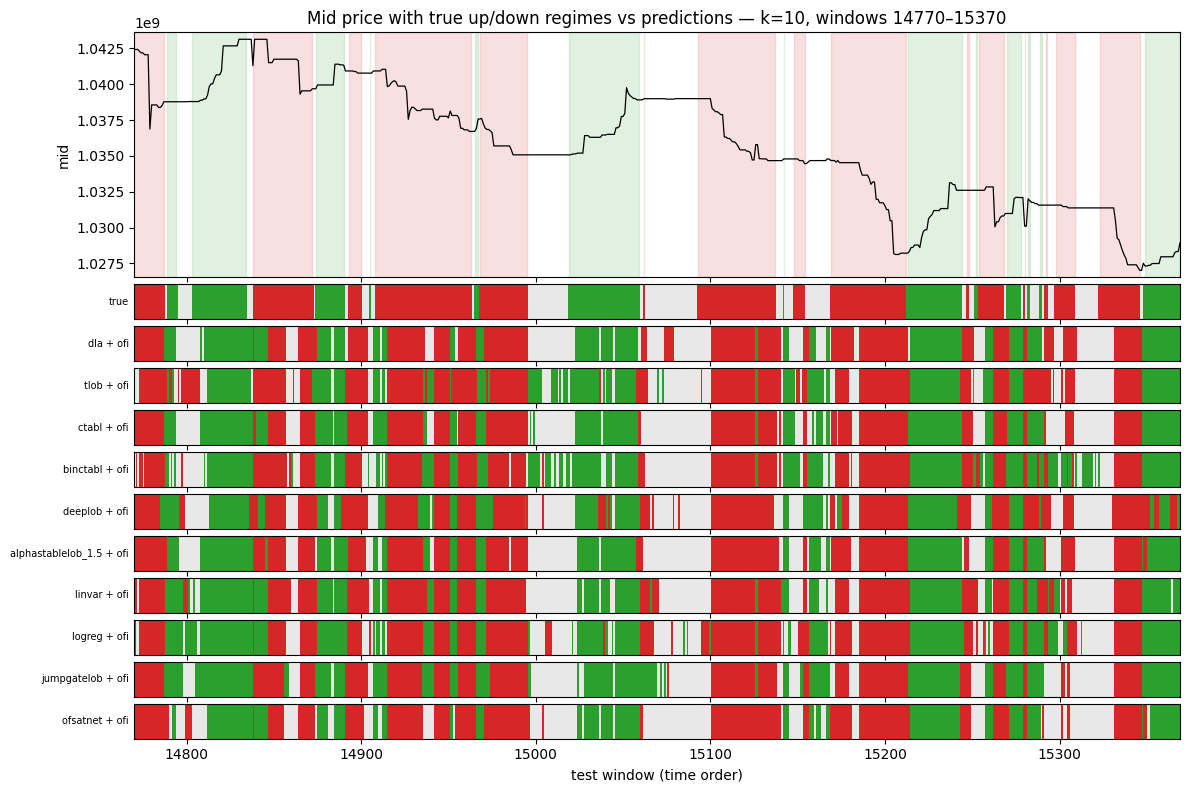

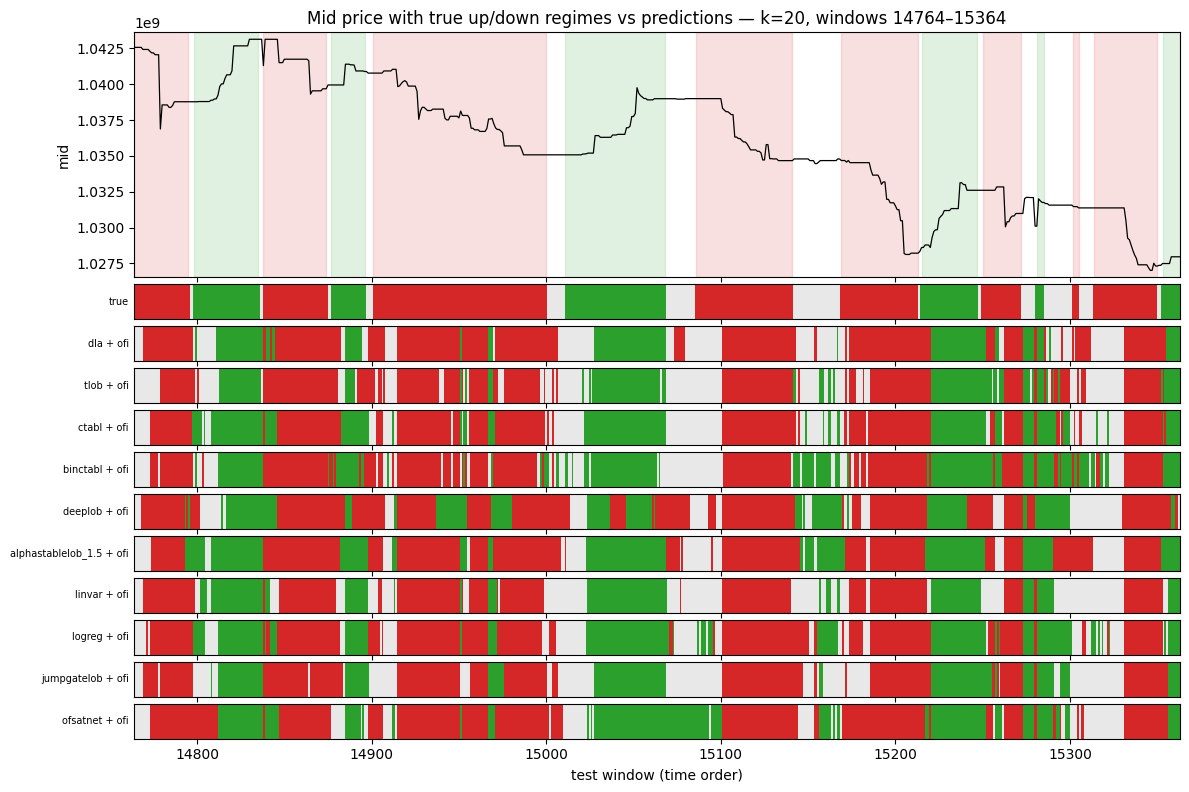

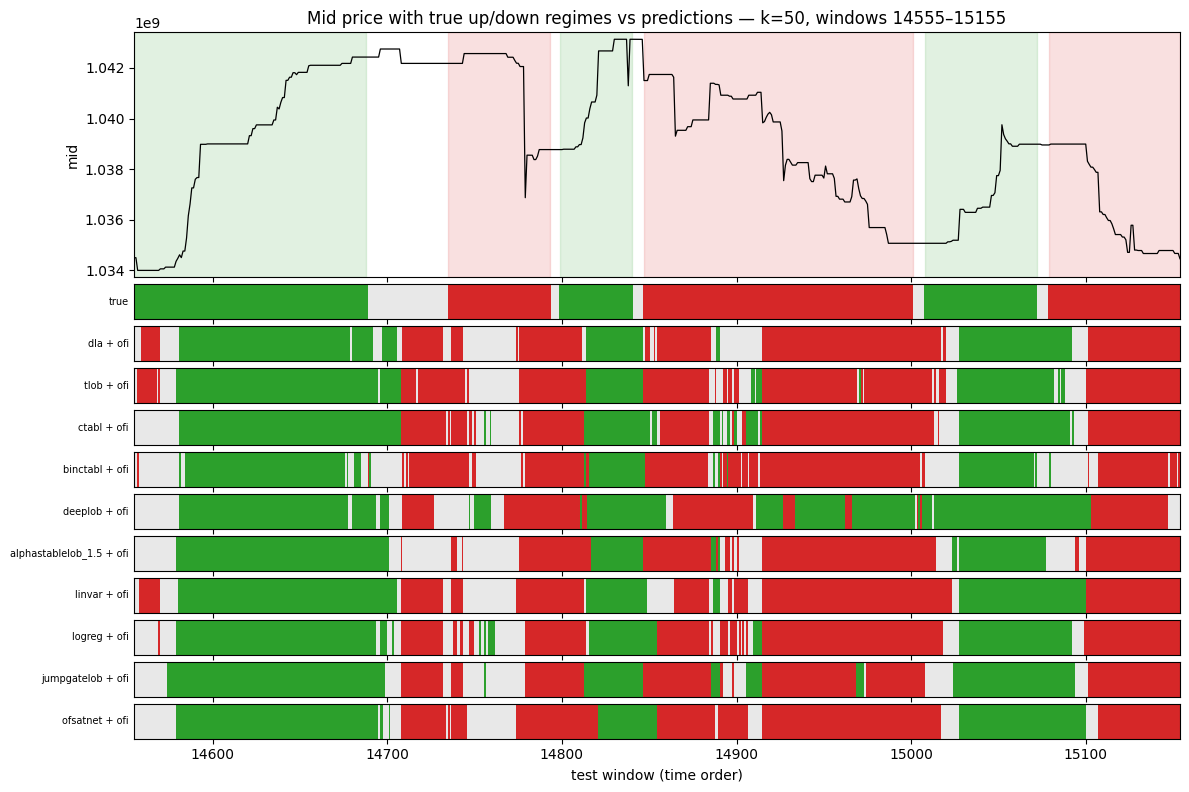

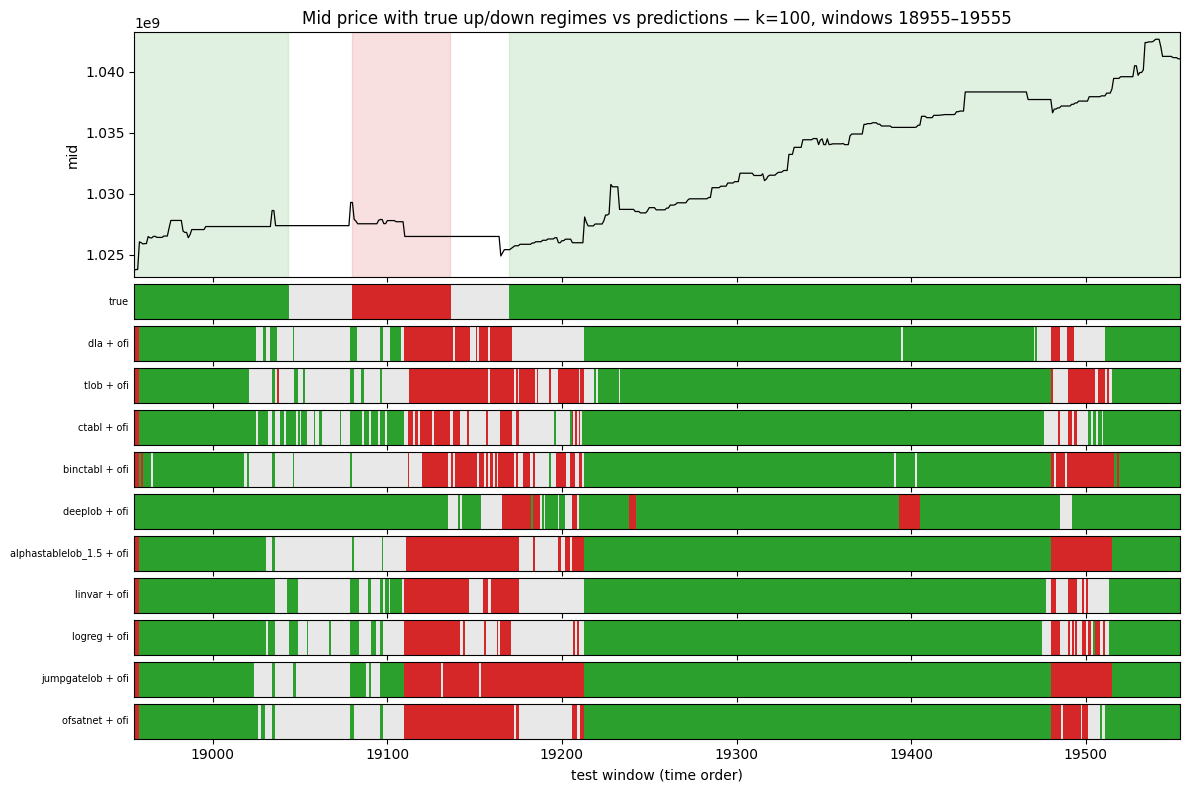

In [15]:
LAB_CMAP = ListedColormap(["#d62728", "#e8e8e8", "#2ca02c"])  # down / flat / up


def plot_price_predictions(k, seg_len=600, start=None):
    tags = [t for t in MODELS if (t, k) in RESULTS]
    m = META.get(k)
    if not tags or m is None:
        return
    y_true = RESULTS[(tags[0], k)]["y_true"]
    tr = np.nan_to_num(m["trend"])
    seg_len = min(seg_len, len(y_true))
    if start is None:  # auto-pick the stretch with the most |trend| mass
        act = np.convolve(np.abs(tr), np.ones(seg_len), "valid")
        start = int(act.argmax())
    sl = slice(start, start + seg_len)
    idx = np.arange(start, start + seg_len)
    price = m["mid"][m["centres"][sl]]
    yt_seg = y_true[sl]

    lanes = [("true", yt_seg)] + [
        (DISPLAY[t], RESULTS[(t, k)]["y_pred"][sl]) for t in tags
    ]
    fig, axes = plt.subplots(
        1 + len(lanes),
        1,
        figsize=(12, 3.4 + 0.42 * len(lanes)),
        sharex=True,
        gridspec_kw={"height_ratios": [7] + [1] * len(lanes)},
    )
    ax = axes[0]
    ax.plot(idx, price, lw=0.9, color="black")
    lo, hi = price.min(), price.max()
    pad = 0.03 * (hi - lo + 1e-9)
    ax.fill_between(
        idx,
        lo - pad,
        hi + pad,
        where=yt_seg == 2,
        color="#2ca02c",
        alpha=0.14,
        step="mid",
    )
    ax.fill_between(
        idx,
        lo - pad,
        hi + pad,
        where=yt_seg == 0,
        color="#d62728",
        alpha=0.14,
        step="mid",
    )
    ax.set_ylim(lo - pad, hi + pad)
    ax.set_ylabel("mid")
    ax.set_title(
        f"Mid price with true up/down regimes vs predictions — "
        f"k={k}, windows {start}–{start + seg_len}"
    )
    for axl, (name, lab) in zip(axes[1:], lanes):
        axl.imshow(
            lab[None, :],
            aspect="auto",
            cmap=LAB_CMAP,
            vmin=0,
            vmax=2,
            extent=[idx[0], idx[-1], 0, 1],
            interpolation="nearest",
        )
        axl.set_yticks([])
        axl.set_ylabel(name, rotation=0, ha="right", va="center", fontsize=7)
    axes[-1].set_xlabel("test window (time order)")
    fig.tight_layout(h_pad=0.15)
    plt.show()


for k in HORIZONS:
    plot_price_predictions(k)

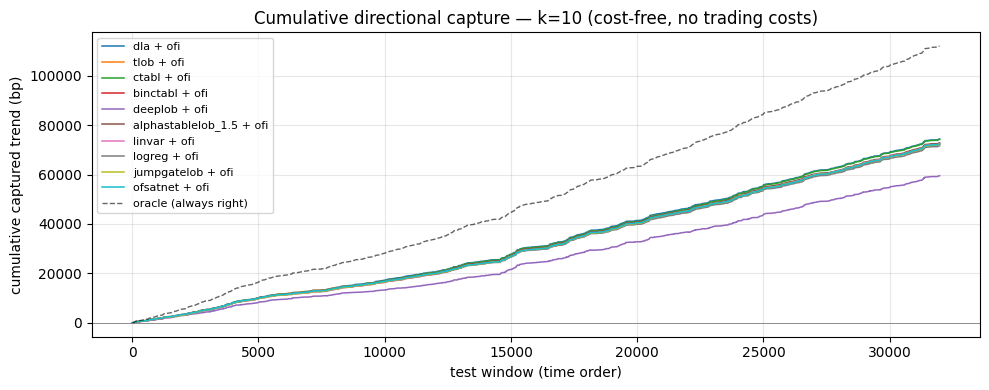

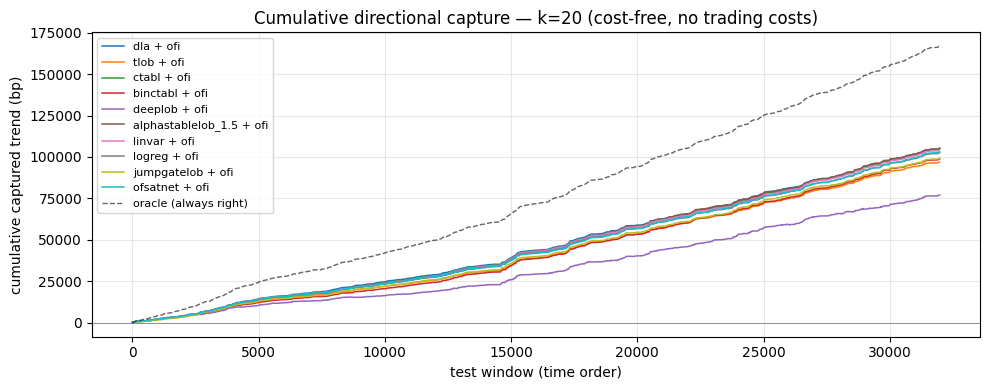

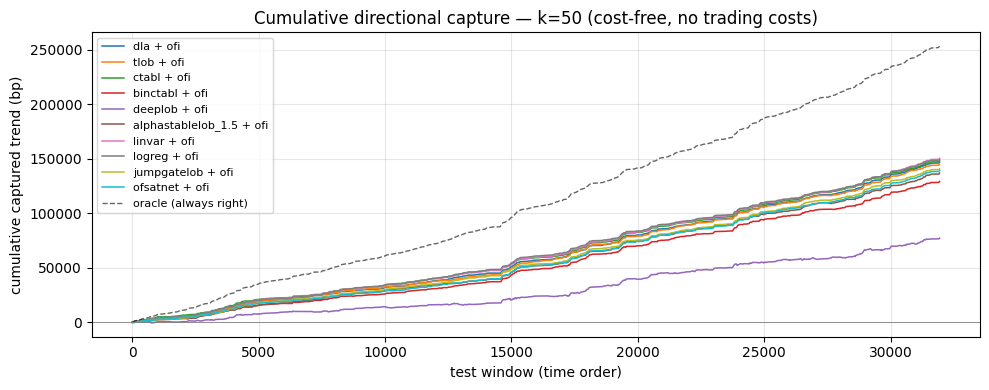

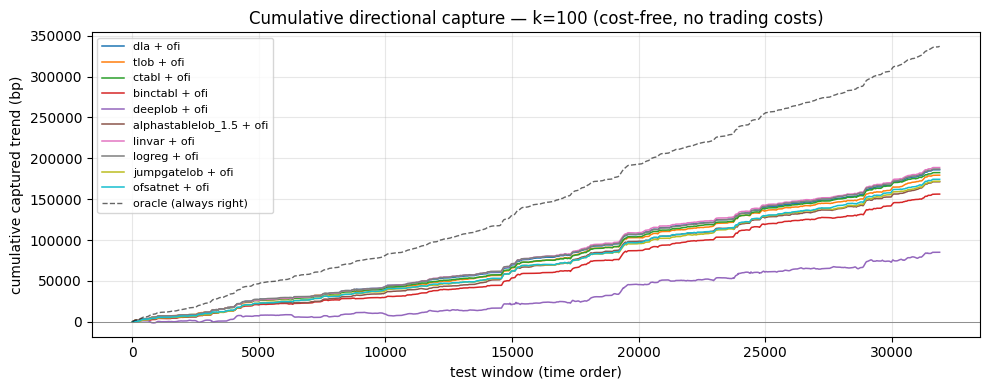

In [16]:
def plot_capture(k):
    tags = [t for t in MODELS if (t, k) in RESULTS]
    m = META.get(k)
    if not tags or m is None:
        return
    tr = np.nan_to_num(m["trend"])
    cmap = plt.get_cmap("tab10")
    fig, ax = plt.subplots(figsize=(10, 4))
    for i, tag in enumerate(tags):
        cap = _positions(RESULTS[(tag, k)]["y_pred"]) * tr
        ax.plot(np.cumsum(cap) * 1e4, color=cmap(i % 10), lw=1.1, label=DISPLAY[tag])
    ax.plot(
        np.cumsum(np.abs(tr)) * 1e4,
        "k--",
        lw=1.0,
        alpha=0.6,
        label="oracle (always right)",
    )
    ax.axhline(0, color="grey", lw=0.6)
    ax.set_xlabel("test window (time order)")
    ax.set_ylabel("cumulative captured trend (bp)")
    ax.set_title(
        f"Cumulative directional capture — k={k} (cost-free, no trading costs)"
    )
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()


for k in HORIZONS:
    plot_capture(k)

### Calibration & confidence gating

Left — reliability: mean accuracy per confidence decile vs the diagonal (a
calibrated model can be *sized* by its probability). Middle/right — trade only when
`p_max ≥ τ` **and** the call is directional: per-signal hit rate and capture (bp) as
the confidence gate tightens. A model whose hit rate and capture rise with τ gives a
usable filter for the later trading simulation.


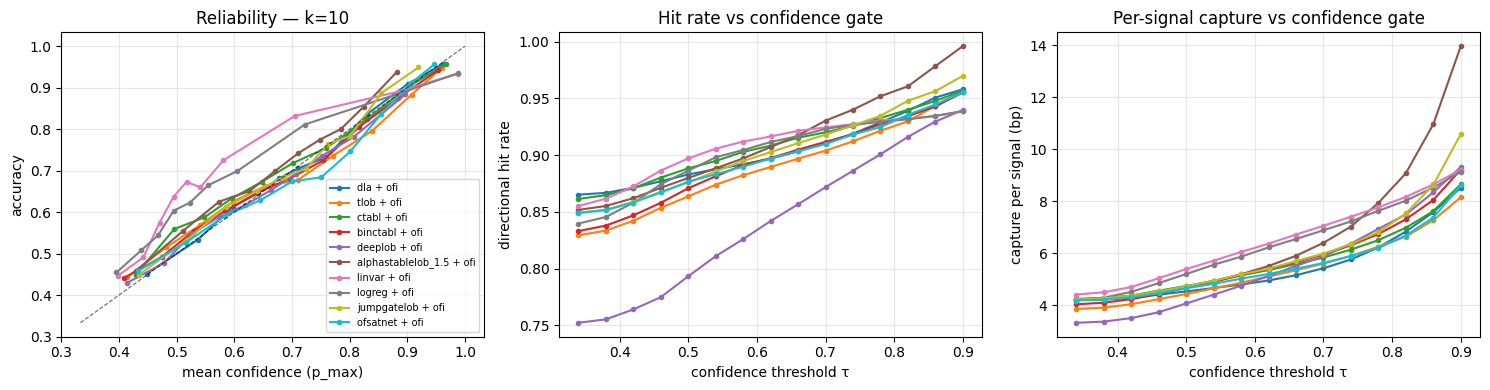

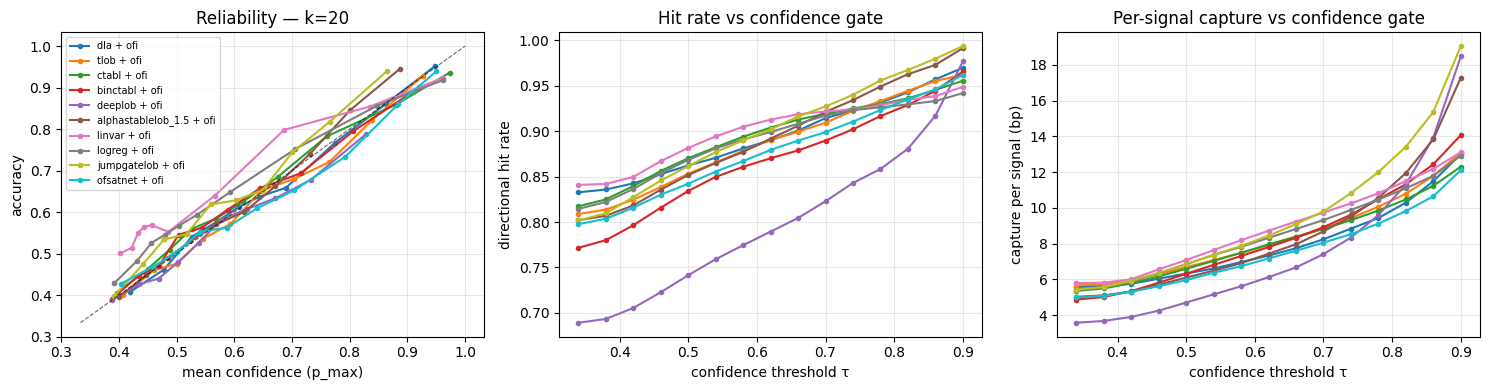

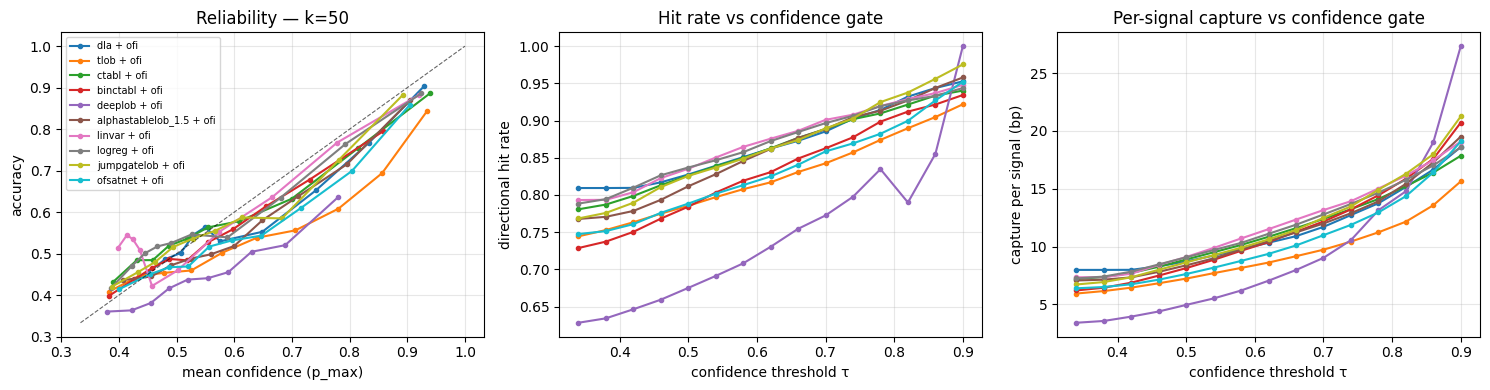

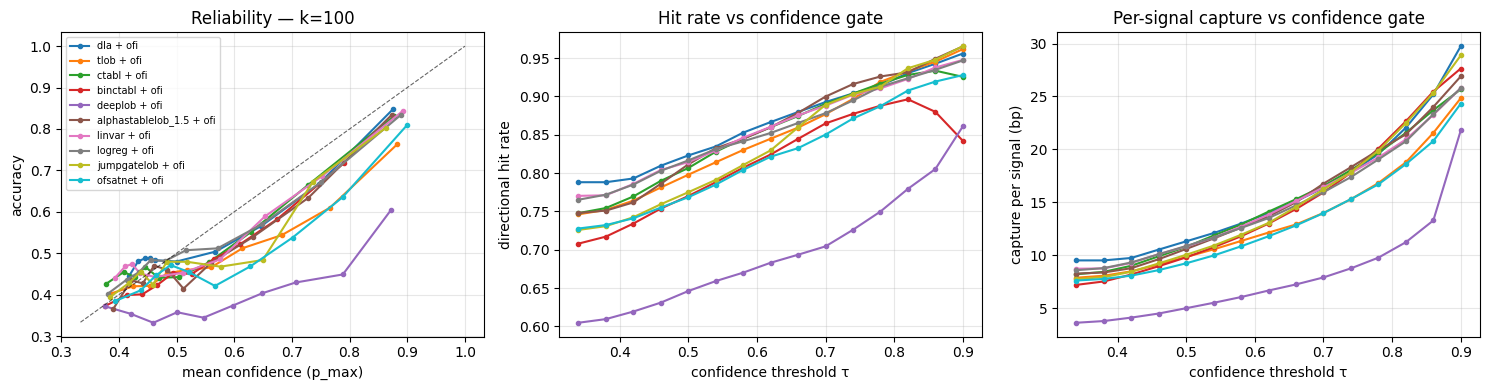

In [17]:
def plot_calibration_gating(k, n_bins=10):
    tags = [t for t in MODELS if (t, k) in RESULTS]
    m = META.get(k)
    if not tags or m is None:
        return
    tr = np.nan_to_num(m["trend"])
    taus = np.linspace(0.34, 0.90, 15)
    cmap = plt.get_cmap("tab10")
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for i, tag in enumerate(tags):
        r = RESULTS[(tag, k)]
        conf = r["probs"].max(1)
        correct = (r["y_true"] == r["y_pred"]).astype(float)
        edges = np.quantile(conf, np.linspace(0, 1, n_bins + 1))
        edges[-1] += 1e-9
        bi = np.clip(np.digitize(conf, edges) - 1, 0, n_bins - 1)
        xs = [
            conf[bi == b].mean() if (bi == b).any() else np.nan for b in range(n_bins)
        ]
        ys = [
            correct[bi == b].mean() if (bi == b).any() else np.nan
            for b in range(n_bins)
        ]
        axes[0].plot(xs, ys, "o-", ms=3, color=cmap(i % 10), label=DISPLAY[tag])
        pos = _positions(r["y_pred"])
        hit, cap = [], []
        for tau in taus:
            sel = (pos != 0) & (conf >= tau)
            hit.append((np.sign(tr[sel]) == pos[sel]).mean() if sel.any() else np.nan)
            cap.append((pos[sel] * tr[sel]).mean() * 1e4 if sel.any() else np.nan)
        axes[1].plot(taus, hit, "o-", ms=3, color=cmap(i % 10))
        axes[2].plot(taus, cap, "o-", ms=3, color=cmap(i % 10))
    axes[0].plot([1 / 3, 1], [1 / 3, 1], "k--", lw=0.8, alpha=0.6)
    axes[0].set_xlabel("mean confidence (p_max)")
    axes[0].set_ylabel("accuracy")
    axes[0].set_title(f"Reliability — k={k}")
    axes[0].legend(fontsize=7)
    axes[1].set_xlabel("confidence threshold τ")
    axes[1].set_ylabel("directional hit rate")
    axes[1].set_title("Hit rate vs confidence gate")
    axes[2].set_xlabel("confidence threshold τ")
    axes[2].set_ylabel("capture per signal (bp)")
    axes[2].set_title("Per-signal capture vs confidence gate")
    for ax in axes:
        ax.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()


for k in HORIZONS:
    plot_calibration_gating(k)

## 7c. Robustness under injected input noise

The headline metrics average over a test set that is mostly *calm*, which dilutes the
one thing the diffusion models were built for. Here we test that property directly:
take **clean** test windows and inject increasing noise ourselves, identically for every
model, then watch how macro-F1 falls off.

Four corruptions, all at overall scale `σ` (features are z-scored, so `σ≈1` is heavy):
- **gaussian** — `x + σ·ξ` (light-tailed baseline).
- **jump** — the JumpGateLOB training kernel: a Gaussian scale mixture `x + √W·ξ`,
  `W = σ² + Σ Gamma jumps`, `N ~ Poisson(σ)` (discrete, jump-like).
- **student_t** — heavy-tailed `x + σ·t_ν` (Student-t, ν=3, standardised to unit
  variance). This is **neither** diffusion model's training kernel, so it is the
  fairest *unseen heavy-tail* stress test.
- **alpha_stable** — the AlphaStableLOB training kernel: subordinated-Gaussian
  α-stable `x + √W·ξ`, `W = σ²·A`, `A ~ PositiveStable(α/2)` (α=1.7, clipped) —
  genuine power-law tails.

The claim to test: JumpGateLOB / AlphaStableLOB curves should stay **flatter** as `σ`
grows, even if they start lower at `σ=0` — most tellingly under `student_t` (unseen by
both) and each model's own kernel (`jump` / `alpha_stable`). **Fair-test caveat:** the
diffusion models trained on heavy-tailed kernels while DLA/CTABL/DeepLOB never saw
injected noise, so a win here is real *robustness to input corruption* but partly a
training-augmentation effect — read it as "does corruption-aware training buy deployment
robustness," not "is the architecture inherently better."

In [18]:
from torch.utils.data import Subset  # noqa: E402

# --- noise sweep config (reduce ROBUST_N / ROBUST_SIGMAS if too slow) ---------
ROBUST_N = 2500  # test windows subsampled
ROBUST_SIGMAS = [0.0, 0.15, 0.3, 0.5, 0.75, 1.0]  # overall noise scale σ
ROBUST_KINDS = ["gaussian", "jump", "student_t", "alpha_stable"]
SIGMA_FOCUS = 0.5  # σ at which calibration / probs are inspected
JUMP = {"rate": 1.0, "shape": 1.0, "scale": 1.0}  # JumpGateLOB levy kernel
STUDENT_NU = 3.0  # Student-t degrees of freedom (heavier as ν→2); var = ν/(ν-2)
ASTABLE_ALPHA = 1.7  # α-stable stability index (α<2 ⇒ power-law tails)
ASTABLE_CLIP_Q = 0.999  # clip the (infinite-mean) subordinator for stability


def perturb(x, sigma, kind, seed):
    """Deterministic input corruption (identical across models given the seed).

    gaussian     — x + σ·ξ                       (light-tailed baseline)
    jump         — x + √W·ξ, W=σ²+ΣGamma jumps   (JumpGateLOB kernel; discrete)
    student_t    — x + σ·t_ν  (ν=3, unit-var)    (heavy-tailed; *neither* kernel)
    alpha_stable — x + √W·ξ, W=σ²·A, A~S⁺_{α/2}  (AlphaStableLOB kernel; power-law)
    """
    torch.manual_seed(seed)  # reproducible randn + _standard_gamma
    eps = torch.randn_like(x)
    if sigma == 0.0 or kind == "gaussian":
        return x + sigma * eps
    v = (-1,) + (1,) * (x.dim() - 1)

    if kind == "jump":
        b = x.shape[0]
        W = torch.full((b,), sigma * sigma)
        N = torch.poisson(torch.full((b,), JUMP["rate"] * sigma))
        m = N > 0
        if m.any():
            W = W.clone()
            W[m] = W[m] + torch._standard_gamma(N[m] * JUMP["shape"]) * JUMP["scale"]
        return x + W.sqrt().view(v) * eps

    if kind == "student_t":
        # standardised Student-t (unit variance for ν>2) → comparable to gaussian σ
        chi2 = torch._standard_gamma(torch.full_like(x, STUDENT_NU / 2.0)) * 2.0
        t = eps / (chi2 / STUDENT_NU).sqrt()
        t = t * ((STUDENT_NU - 2.0) / STUDENT_NU) ** 0.5
        return x + sigma * t

    if kind == "alpha_stable":
        # positive (β=α/2)-stable subordinator A via Kanter (1975); W = σ²·A
        b = x.shape[0]
        beta = ASTABLE_ALPHA / 2.0
        U = torch.rand(b).clamp(1e-7, 1 - 1e-7) * float(np.pi)
        E = (-torch.log(torch.rand(b).clamp_min(1e-12))).clamp_min(1e-12)
        t1 = torch.sin(beta * U) / torch.sin(U).clamp_min(1e-12).pow(1.0 / beta)
        t2 = (torch.sin((1 - beta) * U) / E).clamp_min(1e-30).pow((1 - beta) / beta)
        A = (t1 * t2).clamp_min(1e-12)
        A = A.clamp_max(torch.quantile(A, ASTABLE_CLIP_Q))
        W = (sigma * sigma) * A
        return x + W.sqrt().view(v) * eps

    raise ValueError(f"unknown kind {kind!r}")


@torch.no_grad()
def run_robust_sweep():
    """macro-F1 vs σ for every (model, horizon, kind); stash probs at SIGMA_FOCUS."""
    rows, probs = [], {}
    for k in HORIZONS:
        try:
            test_ds, _, _ = test_set(k)
        except Exception as e:
            print(f"  k={k}: no test set ({e}) — skipped")
            continue
        rng = np.random.default_rng(k)
        idx = np.sort(
            rng.choice(len(test_ds), min(ROBUST_N, len(test_ds)), replace=False)
        )
        sub = Subset(test_ds, idx.tolist())
        for tag in MODELS:
            path = CHECKPOINTS.get(tag, {}).get(k)
            if not path or not Path(path).exists():
                continue
            model = build_model(tag, load_ckpt(path))
            for kind in ROBUST_KINDS:
                loader = DataLoader(sub, batch_size=BATCH, shuffle=False)
                for sig in ROBUST_SIGMAS:
                    yt, yp, prc = [], [], []
                    for bi, b in enumerate(loader):
                        x = b["x"].float()
                        seed = (
                            int(sig * 1000) + bi * 7 + ROBUST_KINDS.index(kind) * 100003
                        )
                        xp = perturb(x, sig, kind, seed)
                        logits = model.predict({"x": xp, "label": b["label"]}, DEVICE)
                        yp.append(logits.argmax(1).cpu().numpy())
                        yt.append(b["label"].numpy())
                        if kind == "jump" and abs(sig - SIGMA_FOCUS) < 1e-9:
                            prc.append(Fn.softmax(logits, 1).cpu().numpy())
                    yt, yp = np.concatenate(yt), np.concatenate(yp)
                    rows.append(
                        {
                            "model": DISPLAY[tag],
                            "k": k,
                            "kind": kind,
                            "sigma": sig,
                            "macro_f1": f1_score(
                                yt,
                                yp,
                                average="macro",
                                labels=[0, 1, 2],
                                zero_division=0,
                            ),
                        }
                    )
                    if prc:
                        probs[(tag, k)] = (yt, yp, np.concatenate(prc))
            del model
            if DEVICE.type == "cuda":
                torch.cuda.empty_cache()
        n_k = len({r["model"] for r in rows if r["k"] == k})
        print(f"  k={k}: swept {n_k} models")
    return pd.DataFrame(rows), probs


print(
    f"running noise sweep — {ROBUST_N} windows × {len(ROBUST_SIGMAS)} σ × "
    f"{len(ROBUST_KINDS)} kinds (gaussian/jump/student_t/alpha_stable)…"
)
robust_df, ROBUST_PROBS = run_robust_sweep()
print(f"done — {len(robust_df)} rows")
robust_df.head()

running noise sweep — 2500 windows × 6 σ × 4 kinds (gaussian/jump/student_t/alpha_stable)…
  k=10: swept 10 models
  k=20: swept 10 models
  k=50: swept 10 models
  k=100: swept 10 models
done — 960 rows


,model,k,kind,sigma,macro_f1
0,dla + ofi,10,gaussian,0.0000,0.6972
1,dla + ofi,10,gaussian,0.1500,0.6100
2,dla + ofi,10,gaussian,0.3000,0.5237
3,dla + ofi,10,gaussian,0.5000,0.4585
4,dla + ofi,10,gaussian,0.7500,0.4227


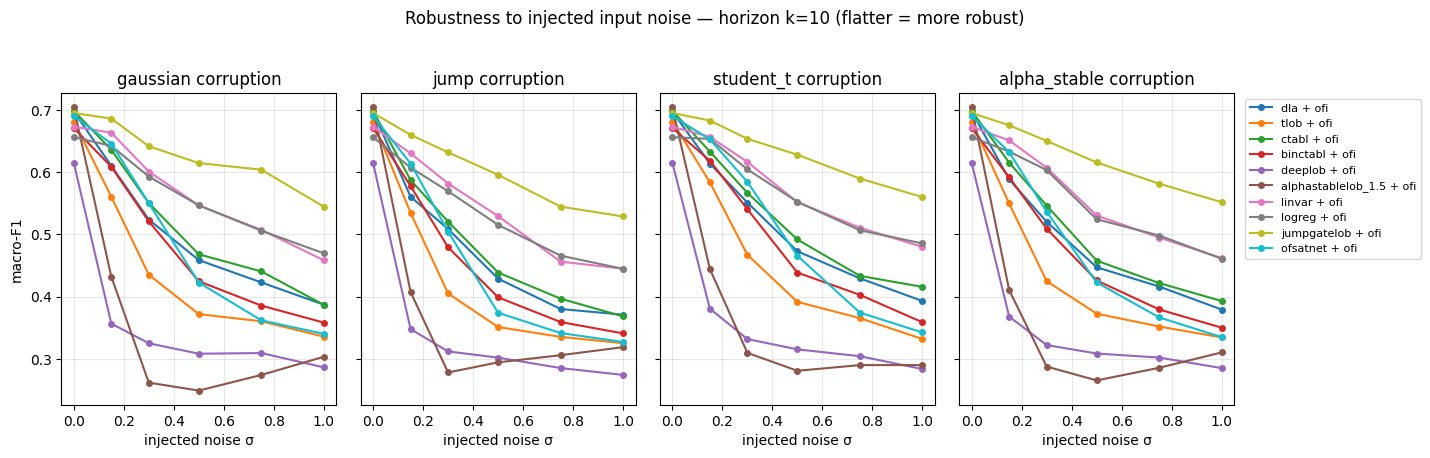

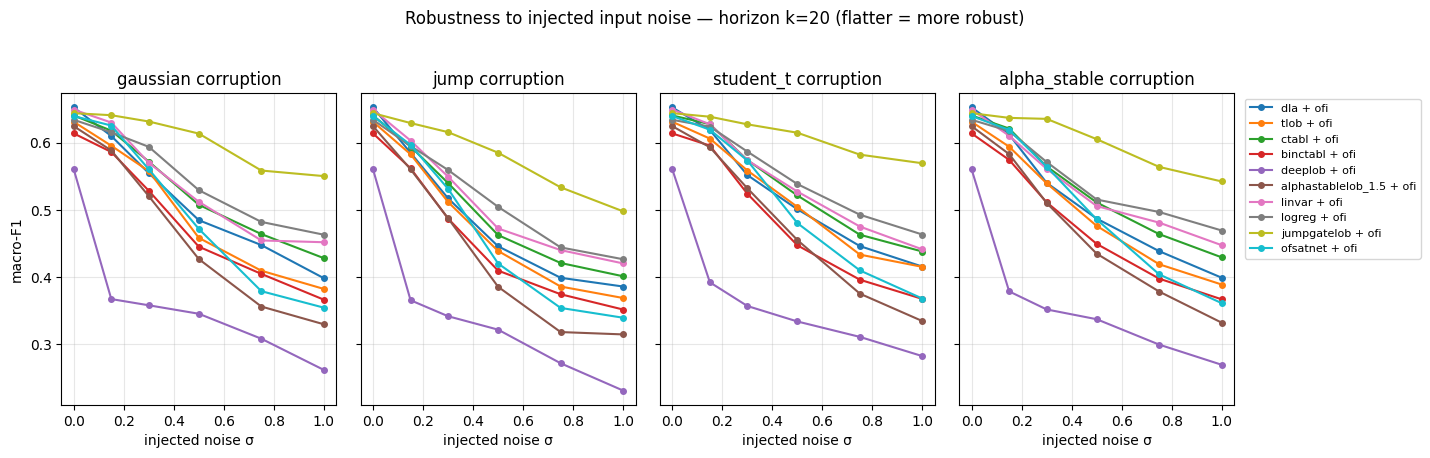

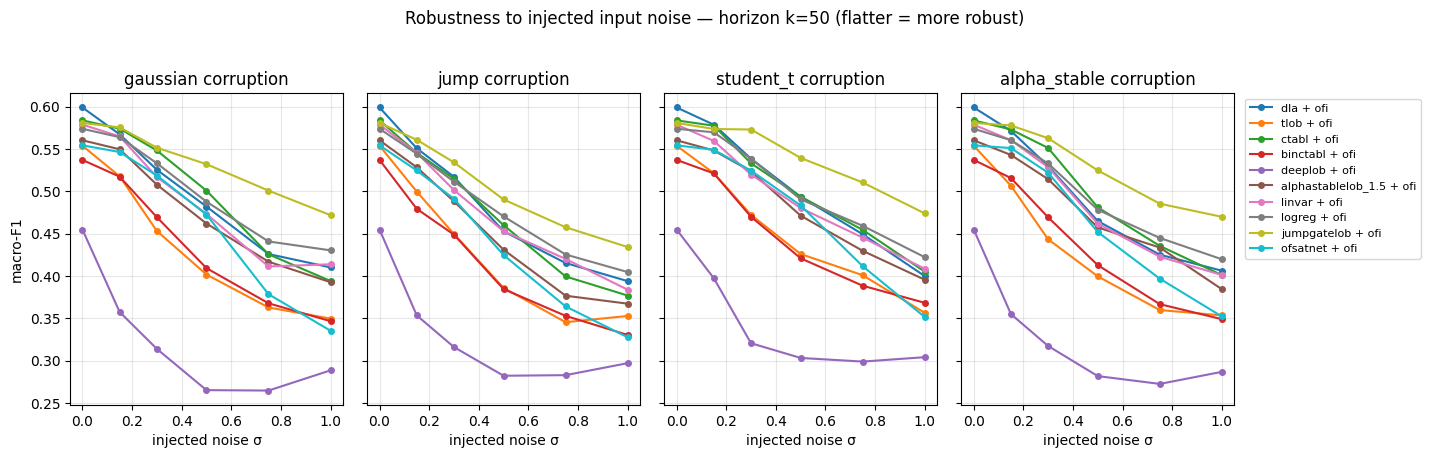

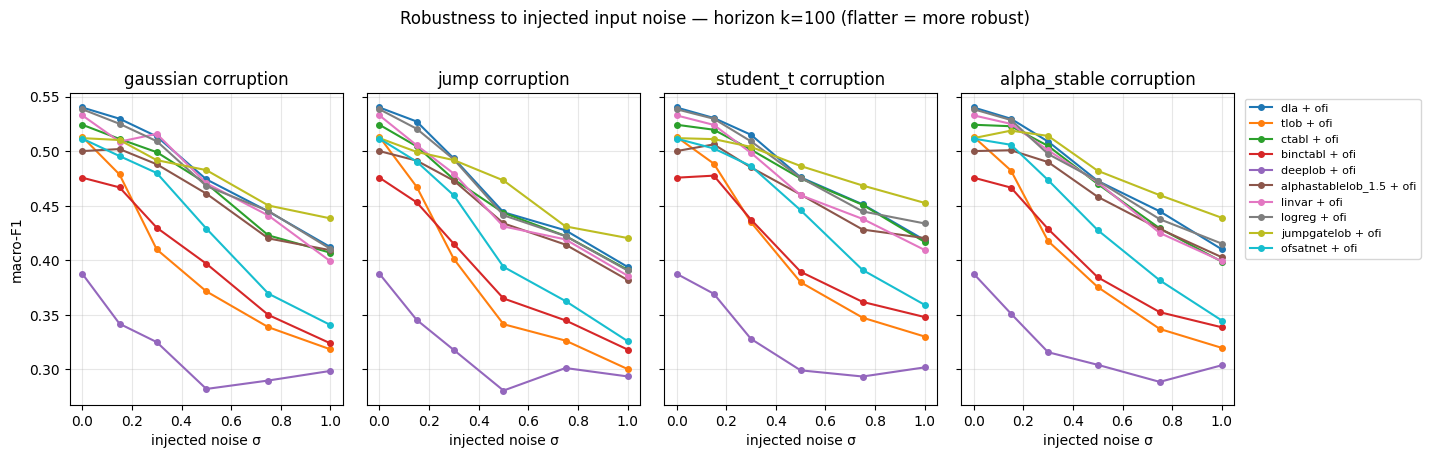


Retention  F1(σ=1.0)/F1(0)  by corruption, mean over horizons (higher = more robust):


kind,gaussian,jump,student_t,alpha_stable,mean
model,,,,,
jumpgatelob + ofi,0.824,0.774,0.845,0.824,0.817
logreg + ofi,0.738,0.694,0.751,0.735,0.729
linvar + ofi,0.708,0.672,0.714,0.702,0.699
ctabl + ofi,0.660,0.628,0.685,0.663,0.659
dla + ofi,0.646,0.621,0.654,0.641,0.640
binctabl + ofi,0.607,0.584,0.628,0.611,0.607
alphastablelob_1.5 + ofi,0.601,0.579,0.603,0.598,0.595
tlob + ofi,0.582,0.566,0.602,0.587,0.584
ofsatnet + ofi,0.572,0.551,0.593,0.581,0.574


In [19]:
# macro-F1 vs injected noise σ — one figure per horizon, one panel per noise kind
def plot_robust_sweep(k):
    if robust_df.empty or "k" not in robust_df.columns:
        return
    sub = robust_df[robust_df["k"] == k]
    if sub.empty:
        return
    cmap = plt.get_cmap("tab10")
    present = [DISPLAY[m] for m in MODELS if DISPLAY[m] in set(sub["model"])]
    n = len(ROBUST_KINDS)
    fig, axes = plt.subplots(1, n, figsize=(3.6 * n, 4.4), sharey=True)
    axes = np.atleast_1d(axes)
    for ax, kind in zip(axes, ROBUST_KINDS):
        d = sub[sub["kind"] == kind]
        for i, name in enumerate(present):
            m = d[d["model"] == name].sort_values("sigma")
            ax.plot(
                m["sigma"], m["macro_f1"], "o-", ms=4, color=cmap(i % 10), label=name
            )
        ax.set_xlabel("injected noise σ")
        ax.set_title(f"{kind} corruption")
        ax.grid(alpha=0.3)
    axes[0].set_ylabel("macro-F1")
    axes[-1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    fig.suptitle(
        f"Robustness to injected input noise — horizon k={k} (flatter = more robust)",
        y=1.03,
    )
    fig.tight_layout()
    plt.show()


for k in HORIZONS:
    plot_robust_sweep(k)

# retention = F1(σ_max)/F1(0) per corruption (mean over horizons); higher = more robust
if not robust_df.empty:
    hi = robust_df["sigma"].max()
    base = (
        robust_df[robust_df["sigma"] == 0.0]
        .groupby(["model", "kind"])["macro_f1"]
        .mean()
    )
    top = (
        robust_df[robust_df["sigma"] == hi]
        .groupby(["model", "kind"])["macro_f1"]
        .mean()
    )
    ret = (top / base.clip(lower=1e-9)).rename("retention").reset_index()
    order = [DISPLAY[m] for m in MODELS if DISPLAY[m] in set(ret["model"])]
    piv = ret.pivot(index="model", columns="kind", values="retention").reindex(order)
    piv = piv[[k for k in ROBUST_KINDS if k in piv.columns]]
    piv["mean"] = piv.mean(axis=1)
    print(
        f"\nRetention  F1(σ={hi})/F1(0)  by corruption, mean over horizons "
        f"(higher = more robust):"
    )
    display(
        piv.sort_values("mean", ascending=False)
        .style.background_gradient(cmap="YlGn", axis=None)
        .format("{:.3f}")
    )

### Calibration under noise

Reliability curves computed on **jump-corrupted** inputs (`σ = SIGMA_FOCUS`). A robust
model keeps its probabilities meaningful when the input degrades — accuracy still tracks
confidence along the diagonal. A brittle one becomes *confidently wrong* (points fall
well below the diagonal at high confidence), which is the dangerous failure mode for a
confidence-gated trading rule.


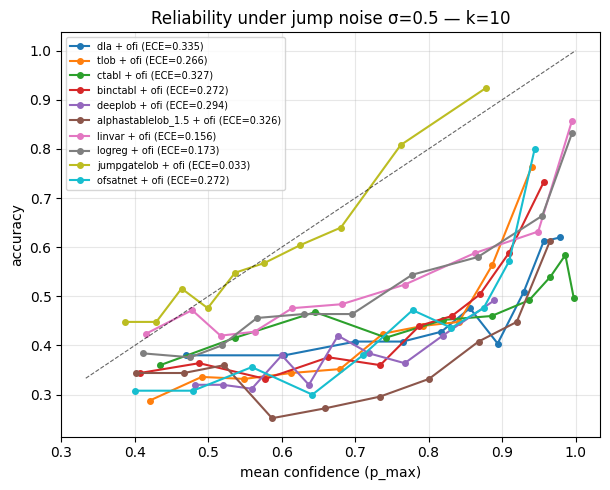

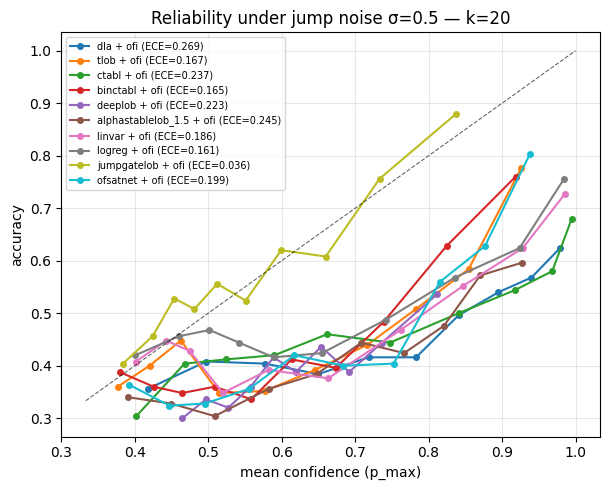

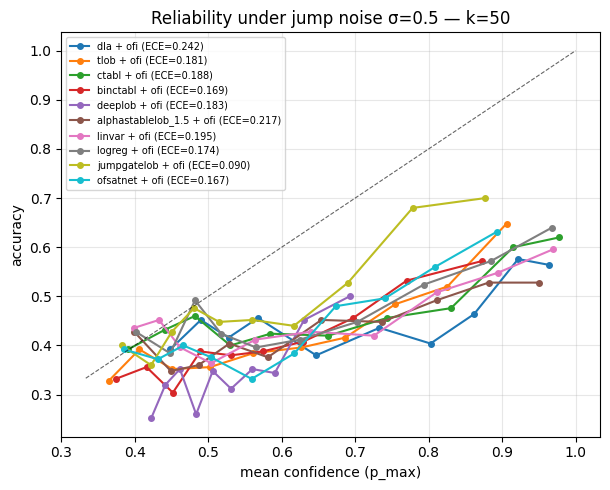

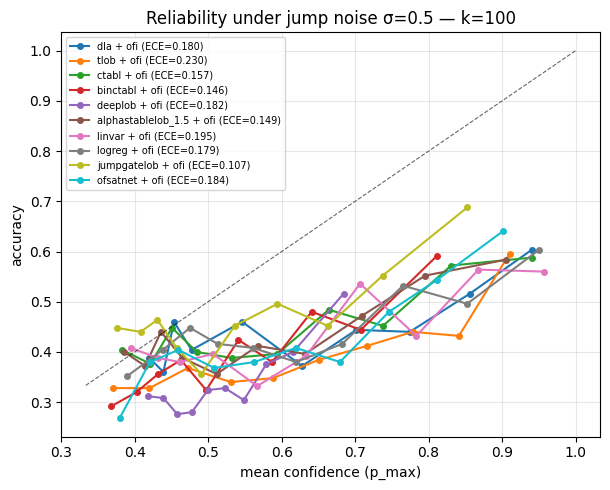

In [20]:
def plot_calibration_under_noise(k, n_bins=10):
    tags = [t for t in MODELS if (t, k) in ROBUST_PROBS]
    if not tags:
        return
    cmap = plt.get_cmap("tab10")
    fig, ax = plt.subplots(figsize=(6.2, 5))
    for i, tag in enumerate(tags):
        yt, yp, pr = ROBUST_PROBS[(tag, k)]
        conf = pr.max(1)
        correct = (yt == yp).astype(float)
        edges = np.quantile(conf, np.linspace(0, 1, n_bins + 1))
        edges[-1] += 1e-9
        bi = np.clip(np.digitize(conf, edges) - 1, 0, n_bins - 1)
        xs = [
            conf[bi == b].mean() if (bi == b).any() else np.nan for b in range(n_bins)
        ]
        ys = [
            correct[bi == b].mean() if (bi == b).any() else np.nan
            for b in range(n_bins)
        ]
        # expected calibration error (bin-weighted |acc − conf|)
        ece = np.nansum(
            [
                (bi == b).mean() * abs(np.nan_to_num(ys[b]) - np.nan_to_num(xs[b]))
                for b in range(n_bins)
            ]
        )
        ax.plot(
            xs,
            ys,
            "o-",
            ms=4,
            color=cmap(i % 10),
            label=f"{DISPLAY[tag]} (ECE={ece:.3f})",
        )
    ax.plot([1 / 3, 1], [1 / 3, 1], "k--", lw=0.8, alpha=0.6)
    ax.set_xlabel("mean confidence (p_max)")
    ax.set_ylabel("accuracy")
    ax.set_title(f"Reliability under jump noise σ={SIGMA_FOCUS} — k={k}")
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()


for k in HORIZONS:
    plot_calibration_under_noise(k)

### Bootstrap confidence intervals on macro-F1

The test set is short (~22 days, one asset), so small macro-F1 gaps may be noise. We
resample the **clean** test windows with replacement (1000×) and report the 95%
interval per model. Overlapping intervals ⇒ the models are statistically
indistinguishable — which reframes "diffusion models rank lower" as "within noise of the
baselines."


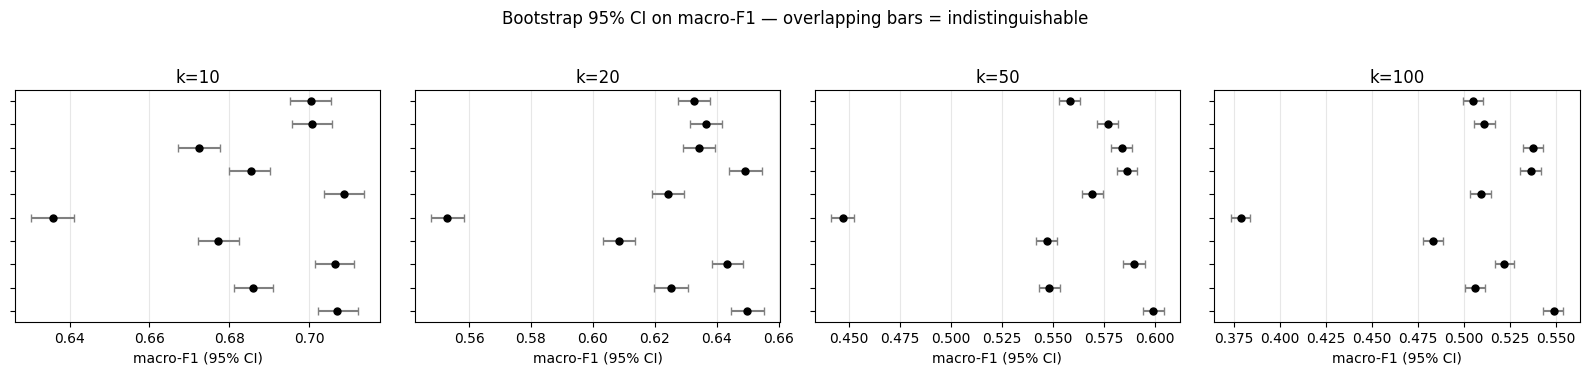

k,10,20,50,100
model,,,,
dla + ofi,0.7070,0.6499,0.5991,0.5490
tlob + ofi,0.6859,0.6251,0.5482,0.5064
ctabl + ofi,0.7063,0.6432,0.5898,0.5222
binctabl + ofi,0.6772,0.6083,0.5471,0.4833
deeplob + ofi,0.6359,0.5531,0.4471,0.3786
alphastablelob_1.5 + ofi,0.7086,0.6243,0.5692,0.5092
linvar + ofi,0.6854,0.6491,0.5861,0.5366
logreg + ofi,0.6725,0.6341,0.5838,0.5377
jumpgatelob + ofi,0.7006,0.6365,0.5768,0.5112


In [21]:
def bootstrap_f1(yt, yp, n=1000, seed=0):
    rng = np.random.default_rng(seed)
    N = len(yt)
    vals = np.empty(n)
    for i in range(n):
        idx = rng.integers(0, N, N)
        vals[i] = f1_score(
            yt[idx], yp[idx], average="macro", labels=[0, 1, 2], zero_division=0
        )
    return vals.mean(), np.percentile(vals, 2.5), np.percentile(vals, 97.5)


boot_rows = []
for (tag, k), r in RESULTS.items():
    mean, lo, hi = bootstrap_f1(r["y_true"], r["y_pred"])
    boot_rows.append({"model": DISPLAY[tag], "k": k, "mean": mean, "lo": lo, "hi": hi})
boot_df = pd.DataFrame(boot_rows)

# forest plot: macro-F1 ± 95% CI per model, one panel per horizon
present = [DISPLAY[m] for m in MODELS if DISPLAY[m] in set(boot_df["model"])]
fig, axes = plt.subplots(
    1, len(HORIZONS), figsize=(4 * len(HORIZONS), 3.6), sharey=True
)
axes = np.atleast_1d(axes)
cmap = plt.get_cmap("tab10")
for ax, k in zip(axes, HORIZONS):
    d = boot_df[boot_df["k"] == k].set_index("model").reindex(present).dropna()
    y = np.arange(len(d))
    ax.errorbar(
        d["mean"],
        y,
        xerr=[d["mean"] - d["lo"], d["hi"] - d["mean"]],
        fmt="o",
        color="black",
        ecolor="grey",
        capsize=3,
        ms=5,
    )
    ax.set_yticks(y, d.index if k == HORIZONS[0] else [""] * len(d), fontsize=8)
    ax.set_title(f"k={k}")
    ax.set_xlabel("macro-F1 (95% CI)")
    ax.grid(alpha=0.3, axis="x")
fig.suptitle(
    "Bootstrap 95% CI on macro-F1 — overlapping bars = indistinguishable", y=1.03
)
fig.tight_layout()
plt.show()
boot_df.pivot(index="model", columns="k", values="mean").reindex(present)

## 8. Final model comparison table

Mean macro-F1 across horizons (overall, calm, extreme) plus the financial
aggregates (mean MCC / capture ratio). `robustness` = extreme / calm.


In [22]:
if RESULTS:
    agg = metrics_df.groupby("model")["macro_f1"].mean().rename("macro_f1_mean")
    parts = [agg]
    if not fin_df.empty:
        parts.append(fin_df.groupby("model")[["mcc", "capture_ratio"]].mean())
    ex = extreme_df.groupby("model")[["f1_calm", "f1_extreme"]].mean()
    parts.append(ex)
    summary = pd.concat(parts, axis=1)
    summary["robustness"] = summary["f1_extreme"] / summary["f1_calm"].clip(lower=1e-9)
    summary = summary.sort_values("macro_f1_mean", ascending=False)
    grad_cols = [
        c
        for c in ["macro_f1_mean", "mcc", "capture_ratio", "f1_calm", "f1_extreme"]
        if c in summary.columns
    ]
    display(
        summary.style.background_gradient(cmap="YlGn", subset=grad_cols).format(
            "{:.4f}"
        )
    )
else:
    print("No results — populate CHECKPOINTS in section 2 and re-run.")

,macro_f1_mean,mcc,capture_ratio,f1_calm,f1_extreme,robustness
model,,,,,,
dla + ofi,0.6263,0.4315,0.6065,0.6260,0.6275,1.0023
ctabl + ofi,0.6155,0.4212,0.6047,0.6143,0.6256,1.0184
linvar + ofi,0.6144,0.4190,0.6061,0.6137,0.6196,1.0097
logreg + ofi,0.6071,0.4080,0.5997,0.6052,0.6239,1.0309
jumpgatelob + ofi,0.6063,0.4096,0.5765,0.6042,0.6247,1.0338
alphastablelob_1.5 + ofi,0.6029,0.4000,0.5825,0.6014,0.6140,1.0210
ofsatnet + ofi,0.5991,0.4008,0.5827,0.5970,0.6181,1.0353
tlob + ofi,0.5914,0.3943,0.5828,0.5910,0.5941,1.0052
binctabl + ofi,0.5789,0.3657,0.5531,0.5763,0.6020,1.0445


In [23]:
# Global knobs for the significance battery. It runs on EVERY (model, horizon)
# in RESULTS — no single target to pick.
H_FWD = None  # forward-return horizon in *windows*; None -> that pair's k
FLAT_THRESHOLD = 0.0  # |score| <= thr counts as "no directional call"
COST_BPS = 5.0  # round-trip cost: half-spread + fees + adverse selection
N_BOOT = 2000  # block-bootstrap resamples
CI = 0.95  # two-sided bootstrap coverage
MEAN_BURN = 250  # burn-in windows before the prevailing mean is trusted
RHO_GRID = [0.0, 0.5, 0.9, 0.95, 0.99]  # AR(1) values swept for breadth deflation
N_REL_BINS = 10  # reliability-diagram / Murphy bins
REL_FOCUS_K = None  # horizon for the reliability-diagram panel; None -> first
print(
    f"significance battery over {len(RESULTS)} (model, horizon) pairs, cost={COST_BPS}bp"
)

significance battery over 40 (model, horizon) pairs, cost=5.0bp


In [24]:
from scipy import stats  # noqa: E402


def _forward_return(mid, centres, h):
    """Log forward mid return over h windows; NaN where the horizon runs off the end."""
    mid = np.asarray(mid, float)
    nxt = centres + h
    ok = nxt < len(mid)
    r = np.full(len(centres), np.nan)
    r[ok] = np.log(mid[nxt[ok]]) - np.log(mid[centres[ok]])
    return r


def build_eval_frame(tag, k, h=None, flat_thr=0.0, cost_bps=COST_BPS):
    """Per-decision-point frame for (tag, k). See section header for column spec.

    r_hat: these are *classifiers* with no native return forecast, so the score
    s = P(up)-P(down) is mapped to return units by a single fixed scale matched to
    the realized-return dispersion (monotone, in-sample). Drop in a genuine model
    point-forecast here if you have one.
    """
    r, m = RESULTS[(tag, k)], META[k]
    h = k if h is None else h
    pr = r["probs"]
    score = pr[:, 2] - pr[:, 0]
    r_fwd = _forward_return(m["mid"], m["centres"], h)
    ss, sr = np.nanstd(score), np.nanstd(r_fwd)
    r_hat = score * (sr / ss if ss > 0 else 0.0)
    ts = np.asarray(m["ts"])[m["centres"]] if "ts" in m else np.arange(len(score))
    df = pd.DataFrame(
        {
            "ts": ts,
            "score": score,
            "pred_class": r["y_pred"],
            "p_down": pr[:, 0],
            "p_flat": pr[:, 1],
            "p_up": pr[:, 2],
            "r_hat": r_hat,
            "r_fwd": r_fwd,
            "cost": cost_bps / 1e4,
        }
    )
    # nested baseline: expanding (out-of-sample) prevailing mean of r_fwd
    rf = df["r_fwd"].to_numpy()
    csum = np.nancumsum(rf)
    cnt = np.cumsum(~np.isnan(rf))
    prev = np.full(len(rf), np.nan)
    prev[1:] = csum[:-1] / np.clip(cnt[:-1], 1, None)
    prev[cnt < MEAN_BURN] = np.nan
    df["r_mean"] = prev
    # non-nested baseline: persistence (previous window's realized fwd return)
    df["r_rw"] = df["r_fwd"].shift(1)
    df["dir_call"] = np.where(
        np.abs(df["score"]) <= flat_thr, 0, np.sign(df["score"])
    ).astype(int)
    return df


def integrated_ac_time(x, max_lag=200):
    """Integrated autocorr time tau = 1 + 2*sum_{l>=1} rho_l (positive part, Sokal).

    Ties the HAC lag and the bootstrap block length to the signal's own memory.
    """
    x = np.asarray(x, float)
    x = x[~np.isnan(x)]
    x = x - x.mean()
    n = len(x)
    denom = np.dot(x, x)
    if denom <= 0 or n < 5:
        return 1.0
    tau, max_lag = 1.0, min(max_lag, n - 1)
    for lag in range(1, max_lag + 1):
        rho = np.dot(x[lag:], x[:-lag]) / denom
        if rho <= 0:  # stop at first non-positive lag
            break
        tau += 2 * rho
    return float(max(tau, 1.0))


# Build one eval frame per (model, horizon), plus its own HAC lag / block length
# (each series gets a lag tied to ITS autocorrelation time and forward horizon).
FRAMES, HACP = {}, {}
for tag, k in RESULTS:
    if META.get(k) is None:
        continue
    fr = build_eval_frame(tag, k, H_FWD, FLAT_THRESHOLD, COST_BPS)
    h_eff = k if H_FWD is None else H_FWD
    ac = int(np.ceil(integrated_ac_time(fr["score"])))
    FRAMES[(tag, k)] = fr
    HACP[(tag, k)] = {
        "h_eff": h_eff,
        "hac_L": int(max(ac, h_eff - 1, 1)),
        "block": int(max(ac, h_eff, 1)),
    }
print(f"built {len(FRAMES)} eval frames")
if FRAMES:
    ex = next(iter(FRAMES))
    print(
        f"example {ex}: rows={len(FRAMES[ex])}  "
        f"usable r_fwd={int(FRAMES[ex]['r_fwd'].notna().sum())}  "
        f"HAC_L={HACP[ex]['hac_L']}  block={HACP[ex]['block']}"
    )
    display(FRAMES[ex].head())

built 40 eval frames
example ('dla', 10): rows=31983  usable r_fwd=31983  HAC_L=9  block=10


,ts,score,pred_class,p_down,p_flat,p_up,r_hat,r_fwd,cost,r_mean,r_rw,dir_call
0,1783661690000000,-0.3999,0,0.6264,0.1471,0.2265,-0.0006,0.0002,0.0005,NaN,NaN,-1
1,1783661690000000,-0.4057,0,0.6232,0.1593,0.2175,-0.0006,0.0002,0.0005,NaN,0.0002,-1
2,1783661700000000,-0.3402,0,0.5736,0.1929,0.2334,-0.0005,0.0002,0.0005,NaN,0.0002,-1
3,1783661710000000,-0.2739,0,0.5115,0.2509,0.2376,-0.0004,0.0002,0.0005,NaN,0.0002,-1
4,1783661720000000,-0.0209,1,0.2979,0.4252,0.2769,-0.0000,0.0004,0.0005,NaN,0.0002,-1


In [25]:
def hac_lrv(x, L):
    """Newey-West (Bartlett) long-run variance of one observation of x.

    gamma_0 + 2 * sum_{l=1..L} (1 - l/(L+1)) gamma_l. Shared by DM and CW so their
    SEs reflect the heavy serial correlation of tick-level loss differentials.
    """
    x = np.asarray(x, float)
    x = x[~np.isnan(x)]
    n = len(x)
    if n < 2:
        return np.nan
    x = x - x.mean()
    lrv = np.dot(x, x) / n
    for lag in range(1, min(L, n - 1) + 1):
        w = 1.0 - lag / (L + 1.0)
        lrv += 2.0 * w * np.dot(x[lag:], x[:-lag]) / n
    return max(lrv, 1e-24)


def hac_se_mean(x, L):
    """HAC standard error of the sample mean of x."""
    x = np.asarray(x, float)
    x = x[~np.isnan(x)]
    return np.sqrt(hac_lrv(x, L) / len(x))


def pesaran_timmermann(pred_sign, real_ret):
    """PT (1992) directional-accuracy test. pred_sign in {-1,0,+1}; flats dropped."""
    mask = ~np.isnan(real_ret) & (pred_sign != 0)
    x = (pred_sign[mask] > 0).astype(float)  # predicted up
    y = (real_ret[mask] > 0).astype(float)  # realized up
    n = len(y)
    if n < 10:
        return {"hit": np.nan, "benchmark": np.nan, "stat": np.nan, "p": np.nan, "n": n}
    P = float(np.mean(x == y))  # hit rate = sign agreement
    Py, Px = y.mean(), x.mean()
    Pstar = Py * Px + (1 - Py) * (1 - Px)  # independence benchmark
    var_P = Pstar * (1 - Pstar) / n
    var_Pstar = (
        ((2 * Py - 1) ** 2) * Px * (1 - Px) / n
        + ((2 * Px - 1) ** 2) * Py * (1 - Py) / n
        + 4 * Py * Px * (1 - Py) * (1 - Px) / n**2
    )
    denom = var_P - var_Pstar
    stat = (P - Pstar) / np.sqrt(denom) if denom > 0 else np.nan
    p = float(1 - stats.norm.cdf(stat)) if np.isfinite(stat) else np.nan
    return {"hit": P, "benchmark": Pstar, "stat": stat, "p": p, "n": n}


def henriksson_merton(pred_sign, real_ret):
    """HM market-timing skill: p_up + p_down - 1, hypergeometric significance."""
    mask = ~np.isnan(real_ret) & (pred_sign != 0)
    ps, rr = pred_sign[mask], real_ret[mask]
    up, dn = rr > 0, rr < 0
    n1, n2 = int(up.sum()), int(dn.sum())
    if n1 < 5 or n2 < 5:
        return {
            "skill": np.nan,
            "p_up": np.nan,
            "p_down": np.nan,
            "stat": np.nan,
            "p": np.nan,
        }
    p_up = float(np.mean(ps[up] > 0))  # correct given up
    p_dn = float(np.mean(ps[dn] < 0))  # correct given down
    n = n1 + n2
    N1 = int((ps > 0).sum())  # predicted up
    n11 = int(((ps > 0) & up).sum())  # correct up
    E = N1 * n1 / n
    V = N1 * n1 * (n - N1) * (n - n1) / (n**2 * (n - 1))
    stat = (n11 - E) / np.sqrt(V) if V > 0 else np.nan
    p = float(1 - stats.norm.cdf(stat)) if np.isfinite(stat) else np.nan
    return {
        "skill": p_up + p_dn - 1,
        "p_up": p_up,
        "p_down": p_dn,
        "stat": stat,
        "p": p,
    }


def diebold_mariano(r, f1, f2, L, h=1):
    """DM squared-error test, model f1 vs NON-NESTED baseline f2, HAC SE + HLN fix.

    d = e1^2 - e2^2; a significantly negative mean => model f1 has lower loss.
    """
    m = ~np.isnan(r) & ~np.isnan(f1) & ~np.isnan(f2)
    e1, e2 = r[m] - f1[m], r[m] - f2[m]
    d = e1**2 - e2**2
    n = len(d)
    if n < 10:
        return {"dbar": np.nan, "stat": np.nan, "p": np.nan, "n": n}
    se = hac_se_mean(d, L)
    stat = d.mean() / se if se > 0 else np.nan
    stat *= np.sqrt((n + 1 - 2 * h + h * (h - 1) / n) / n)  # Harvey-Leybourne-Newbold
    p = float(2 * (1 - stats.norm.cdf(abs(stat)))) if np.isfinite(stat) else np.nan
    return {"dbar": float(d.mean()), "stat": stat, "p": p, "n": n}


def clark_west(r, f_unrestr, f_restr, L):
    """CW test, model f_unrestr vs NESTED baseline f_restr (e.g. prevailing mean).

    f = (r - f_restr)^2 - [(r - f_unrestr)^2 - (f_restr - f_unrestr)^2]. The last
    term strips the estimation-noise penalty that biases plain DM against the
    larger model. One-sided: fbar>0 => the extra structure earns its keep OOS.
    """
    m = ~np.isnan(r) & ~np.isnan(f_unrestr) & ~np.isnan(f_restr)
    r_, fu, fr = r[m], f_unrestr[m], f_restr[m]
    f = (r_ - fr) ** 2 - ((r_ - fu) ** 2 - (fr - fu) ** 2)
    n = len(f)
    if n < 10:
        return {"fbar": np.nan, "stat": np.nan, "p": np.nan, "n": n}
    se = hac_se_mean(f, L)
    stat = f.mean() / se if se > 0 else np.nan
    p = float(1 - stats.norm.cdf(stat)) if np.isfinite(stat) else np.nan
    return {"fbar": float(f.mean()), "stat": stat, "p": p, "n": n}


def campbell_thompson_r2(r, f_model, f_mean):
    """OOS R^2 vs the prevailing mean; positive => model beats the running mean."""
    m = ~np.isnan(r) & ~np.isnan(f_model) & ~np.isnan(f_mean)
    num = np.sum((r[m] - f_model[m]) ** 2)
    den = np.sum((r[m] - f_mean[m]) ** 2)
    return float(1 - num / den) if den > 0 else np.nan

### 9.3 Economic value

Information coefficient, Fundamental Law with breadth deflation, conditional
separation, break-even cost, and calibration. Bootstrap CIs use circular blocks
of length `BLOCK_LEN` (the same autocorrelation time that set `HAC_L`).

In [26]:
def block_bootstrap_ci(func, arrays, block, n_boot=None, ci=None, seed=0):
    """Circular-block-bootstrap CI for a statistic of one or more aligned arrays."""
    n_boot = N_BOOT if n_boot is None else n_boot
    ci = CI if ci is None else ci
    rng = np.random.default_rng(seed)
    arrays = [np.asarray(a, float) for a in arrays]
    n = len(arrays[0])
    nb = int(np.ceil(n / block))
    vals = []
    for _ in range(n_boot):
        starts = rng.integers(0, n, nb)
        idx = np.concatenate([(np.arange(s, s + block) % n) for s in starts])[:n]
        v = func(*[a[idx] for a in arrays])
        if np.isfinite(v):
            vals.append(v)
    vals = np.array(vals)
    lo, hi = np.percentile(vals, [100 * (1 - ci) / 2, 100 * (1 + ci) / 2])
    return float(np.mean(vals)), float(lo), float(hi)


def boot_group_diff(a, b, block, n_boot=None, ci=None, seed=3):
    """Block-bootstrap CI for mean(a) - mean(b) (each group resampled separately)."""
    n_boot = N_BOOT if n_boot is None else n_boot
    ci = CI if ci is None else ci
    rng = np.random.default_rng(seed)
    a, b = np.asarray(a, float), np.asarray(b, float)
    if len(a) < 2 or len(b) < 2:
        return np.nan, np.nan, np.nan

    def bmean(x):
        n = len(x)
        nb = int(np.ceil(n / block))
        s = rng.integers(0, n, nb)
        idx = np.concatenate([(np.arange(t, t + block) % n) for t in s])[:n]
        return x[idx].mean()

    d = np.array([bmean(a) - bmean(b) for _ in range(n_boot)])
    lo, hi = np.percentile(d, [100 * (1 - ci) / 2, 100 * (1 + ci) / 2])
    return float(d.mean()), float(lo), float(hi)


def _pearson(a, b):
    m = ~np.isnan(a) & ~np.isnan(b)
    return float(np.corrcoef(a[m], b[m])[0, 1]) if m.sum() > 2 else np.nan


def _spearman(a, b):
    m = ~np.isnan(a) & ~np.isnan(b)
    return float(stats.spearmanr(a[m], b[m]).correlation) if m.sum() > 2 else np.nan


def jonckheere_terpstra(groups):
    """JT trend test for monotone increase across ordered groups (normal approx)."""
    groups = [np.asarray(g, float) for g in groups]
    groups = [g[~np.isnan(g)] for g in groups]
    ns = np.array([len(g) for g in groups])
    N = ns.sum()
    JT = 0.0
    for i in range(len(groups)):
        for j in range(i + 1, len(groups)):
            diff = groups[j][:, None] - groups[i][None, :]  # Mann-Whitney count
            JT += np.sum(diff > 0) + 0.5 * np.sum(diff == 0)
    mu = (N**2 - np.sum(ns**2)) / 4.0
    var = (N**2 * (2 * N + 3) - np.sum(ns**2 * (2 * ns + 3))) / 72.0
    z = (JT - mu) / np.sqrt(var) if var > 0 else np.nan
    p = float(1 - stats.norm.cdf(z)) if np.isfinite(z) else np.nan  # one-sided (up)
    return {"JT": float(JT), "z": float(z) if np.isfinite(z) else np.nan, "p": p}


def brier_multiclass(probs, y):
    oh = np.eye(probs.shape[1])[y]
    return float(np.mean(np.sum((probs - oh) ** 2, axis=1)))


def murphy_decomposition(f, o, n_bins=None):
    """Binary Brier = Reliability - Resolution + Uncertainty (Murphy 1973).

    f = forecast prob, o in {0,1}. reliability lower is better; resolution higher.
    """
    n_bins = N_REL_BINS if n_bins is None else n_bins
    edges = np.linspace(0, 1, n_bins + 1)
    edges[-1] += 1e-9
    b = np.clip(np.digitize(f, edges) - 1, 0, n_bins - 1)
    obar = o.mean()
    rel = res = 0.0
    xs, ys, ns = [], [], []
    for k in range(n_bins):
        mask = b == k
        nk = int(mask.sum())
        if nk == 0:
            continue
        fk, ok = f[mask].mean(), o[mask].mean()
        rel += nk * (fk - ok) ** 2
        res += nk * (ok - obar) ** 2
        xs.append(fk)
        ys.append(ok)
        ns.append(nk)
    n = len(f)
    return {
        "reliability": rel / n,
        "resolution": res / n,
        "uncertainty": float(obar * (1 - obar)),
        "brier": float(np.mean((f - o) ** 2)),
        "bins": (np.array(xs), np.array(ys), np.array(ns)),
    }

In [ ]:
# Run every statistical + economic metric on every (model, horizon). Results land
# in SIG[(tag, k)] (full dicts) and SIG_ROWS (one tidy record per pair).
def run_significance(tag, k):
    F = FRAMES[(tag, k)]
    hp = HACP[(tag, k)]
    L, block, h = hp["hac_L"], hp["block"], hp["h_eff"]
    ps, rf = F["dir_call"].to_numpy(), F["r_fwd"].to_numpy()
    rhat, rrw, rmean = (
        F["r_hat"].to_numpy(),
        F["r_rw"].to_numpy(),
        F["r_mean"].to_numpy(),
    )
    out = {}
    out["PT"] = pesaran_timmermann(ps, rf)
    out["HM"] = henriksson_merton(ps, rf)
    out["DM_rw"] = diebold_mariano(rf, rhat, rrw, L, h=h)
    out["CW"] = clark_west(rf, rhat, rmean, L)
    out["CT_R2"] = campbell_thompson_r2(rf, rhat, rmean)

    sc = F["score"].to_numpy()
    m = ~np.isnan(sc) & ~np.isnan(rf)
    sc_, rf_ = sc[m], rf[m]
    out["IC_pearson"] = (
        _pearson(sc_, rf_),
        *block_bootstrap_ci(_pearson, (sc_, rf_), block, seed=1)[1:],
    )
    out["IC_spearman"] = (
        _spearman(sc_, rf_),
        *block_bootstrap_ci(_spearman, (sc_, rf_), block, seed=2)[1:],
    )
    ic0 = _pearson(sc_, rf_)
    rho_hat = _pearson(sc_[1:], sc_[:-1])
    flam_rows = []
    for rho in sorted(set(RHO_GRID + [round(float(rho_hat), 3)])):
        defl = (1 - rho) / (1 + rho)
        br_eff = len(sc_) * defl
        flam_rows.append(
            {
                "rho": rho,
                "breadth_defl": defl,
                "BR_eff": br_eff,
                "IR": ic0 * np.sqrt(max(br_eff, 0.0)),
            }
        )
    out["FLAM"] = {
        "ic": ic0,
        "rho_hat": float(rho_hat),
        "table": pd.DataFrame(flam_rows),
    }

    pc = F["pred_class"].to_numpy()
    grp = {c: rf[(pc == c) & ~np.isnan(rf)] for c in (0, 1, 2)}
    edge = boot_group_diff(grp[2], grp[0], block)
    out["SEP"] = {
        "means_bp": {
            c: float(np.nanmean(grp[c]) * 1e4) if len(grp[c]) else np.nan for c in grp
        },
        "edge_bp": (edge[0] * 1e4, edge[1] * 1e4, edge[2] * 1e4),
        "JT": jonckheere_terpstra([grp[0], grp[1], grp[2]]),
    }

    c = float(F["cost"].iloc[0])
    dcall = F["dir_call"].to_numpy()
    dmask = (dcall != 0) & ~np.isnan(rf)
    pnl = dcall[dmask] * rf[dmask]
    up_mask = (pc == 2) & ~np.isnan(rf)
    up_move = float(np.nanmean(rf[up_mask])) if up_mask.any() else np.nan
    rhat_mag = np.abs(rhat[dmask])
    clears = float(np.mean(rhat_mag > c)) if len(rhat_mag) else np.nan
    wins, losses = pnl[pnl > 0], -pnl[pnl < 0]
    W = wins.mean() if len(wins) else np.nan
    Lm = losses.mean() if len(losses) else np.nan
    p_star = (Lm + c) / (W + Lm) if np.isfinite(W + Lm) and (W + Lm) > 0 else np.nan
    out["BE"] = {
        "up_move_bp": up_move * 1e4,
        "cost_bp": c * 1e4,
        "frac_clears": clears,
        "W_bp": W * 1e4,
        "L_bp": Lm * 1e4,
        "p_star": float(p_star) if np.isfinite(p_star) else np.nan,
        "hit": float(np.mean(pnl > 0)) if len(pnl) else np.nan,
    }

    probs = RESULTS[(tag, k)]["probs"]
    yv = RESULTS[(tag, k)]["y_true"]
    out["BRIER_MC"] = brier_multiclass(probs, yv)
    out["MURPHY"] = murphy_decomposition(probs[:, 2], (yv == 2).astype(float))
    return out


SIG, SIG_ROWS = {}, []
for tag, k in sorted(RESULTS, key=lambda tk: (tk[1], tk[0])):
    if (tag, k) not in FRAMES:
        continue
    r = run_significance(tag, k)
    SIG[(tag, k)] = r
    SIG_ROWS.append(
        {
            "model": DISPLAY[tag],
            "k": k,
            "pt_hit": r["PT"]["hit"],
            "pt_p": r["PT"]["p"],
            "hm_skill": r["HM"]["skill"],
            "hm_p": r["HM"]["p"],
            "dm_dbar": r["DM_rw"]["dbar"],
            "dm_p": r["DM_rw"]["p"],
            "cw_fbar": r["CW"]["fbar"],
            "cw_p": r["CW"]["p"],
            "ct_r2_pct": r["CT_R2"] * 100,
            "ic_pearson": r["IC_pearson"][0],
            "ic_spearman": r["IC_spearman"][0],
            "ir_rho_hat": float(
                r["FLAM"]["table"].iloc[
                    (r["FLAM"]["table"]["rho"] - r["FLAM"]["rho_hat"]).abs().idxmin()
                ]["IR"]
            ),
            "rho_hat": r["FLAM"]["rho_hat"],
            "edge_bp": r["SEP"]["edge_bp"][0],
            "jt_p": r["SEP"]["JT"]["p"],
            "be_pstar": r["BE"]["p_star"],
            "be_hit": r["BE"]["hit"],
            "frac_clears": r["BE"]["frac_clears"],
            "brier_mc": r["BRIER_MC"],
            "reliability": r["MURPHY"]["reliability"],
            "resolution": r["MURPHY"]["resolution"],
        }
    )
sig_df = pd.DataFrame(SIG_ROWS)
print(f"scored {len(SIG)} (model, horizon) pairs")
sig_df

> **On the tiny $R^2_{\text{OOS}}$.** At LOB frequency a Campbell–Thompson
> $R^2$ below ~1% is *expected*, not a failure: forward mid returns are almost
> pure noise, so even a real edge explains little variance. What matters is
> whether that sliver is (a) statistically robust (DM/CW above) and (b)
> economically large after the trade multiplier — quantified in the economic
> layer next.

> **Calibration is only load-bearing if you size on probabilities.** If the
> strategy just acts on the argmax class, skip the Brier / Murphy block; it
> matters when `p_up` drives position size, where a well-resolved, low-reliability
> forecast can be scaled and a miscalibrated one cannot.